In [1]:
import os
print(os.path.abspath('.'))

/users/PAS2015/pingwei821/model1/consolidated_pipeline/irAE_model_202507/external_validation/demo/Evidence_consolidation


In [55]:
import pandas as pd
import ast
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import re

In [4]:
p1 = pd.read_csv('../LLM_inference/llm_results/llm_df1.csv')
p2 = pd.read_csv('../LLM_inference/llm_results/llm_df2.csv')
p3 = pd.read_csv('../LLM_inference/llm_results/llm_df3.csv')
p4 = pd.read_csv('../LLM_inference/llm_results/llm_df4.csv')
p5 = pd.read_csv('../LLM_inference/llm_results/llm_df5.csv')
p6 = pd.read_csv('../LLM_inference/llm_results/llm_df6.csv')


In [8]:
import re
import json

def parse_response(response_string):
    pattern = r'```json\s*(.*?)\s*```'
    match = re.search(pattern, response_string, re.DOTALL)

    if match:
        content = match.group(1).strip()
    else:
        content = response_string.strip()

    # 1️⃣ 先尝试正常 json
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        pass

    # 2️⃣ 修正裸 None → "None"
    try:
        cleaned = content

        # 只替换 value 是 None 的情况
        # 匹配 : None  或  :None
        cleaned = re.sub(r':\s*None\b', r': "None"', cleaned)

        # 删除可能的 trailing comma
        cleaned = re.sub(r',\s*}', '}', cleaned)
        cleaned = re.sub(r',\s*]', ']', cleaned)

        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    # 3️⃣ 最后 fallback
    try:
        parsed = ast.literal_eval(content)

        # 如果 literal_eval 成功，也确保 None 被转成字符串
        if isinstance(parsed, dict):
            parsed = {
                k: ("None" if v is None else v)
                for k, v in parsed.items()
            }
        return parsed
    except:
        return 'parse_failed'

def dedup_parse(dfi):
    dfi = dfi.drop_duplicates().copy()
    dfi['llm_output'] = dfi['output'].apply(lambda x: parse_response(x))
    return dfi
    
# df1 = dedup_parse(p1)
# df2 = dedup_parse(p2)
# df3 = dedup_parse(p3)
# df4 = dedup_parse(p4)
# df5 = dedup_parse(p5)

In [6]:
info_order = [['Y', 'Y', 'Y', 'Y'], ['Y', 'Y', 'Y', 'N'], ['Y', 'Y', 'O', 'Y'], ['Y', 'Y', 'O', 'N'], ['Y', 'Y', 'N', 'Y'], ['Y', 'Y', 'N', 'N'],
              ['Y', 'N', 'Y', 'Y'], ['Y', 'N', 'Y', 'N'], ['Y', 'N', 'O', 'Y'], ['Y', 'N', 'O', 'N'], ['Y', 'N', 'N', 'Y'], ['Y', 'N', 'N', 'N'],
              ['N', 'Y', 'Y', 'Y'], ['N', 'Y', 'Y', 'N'], ['N', 'Y', 'O', 'Y'], ['N', 'Y', 'O', 'N'], ['N', 'Y', 'N', 'Y'], ['N', 'Y', 'N', 'N'],
              ['N', 'N', 'Y', 'Y'], ['N', 'N', 'Y', 'N'], ['N', 'N', 'O', 'Y'], ['N', 'N', 'O', 'N'], ['N', 'N', 'N', 'Y'], ['N', 'N', 'N', 'N']]

# # 1️⃣ 生成优先级字典
# priority_map = {tuple(v): i for i, v in enumerate(info_order)}

# # 2️⃣ 生成 tuple 列
# testing['combo'] = list(zip(testing['m1'], testing['m2'], testing['m4'], testing['m5']))

# # 3️⃣ 打分
# testing['priority'] = testing['combo'].map(priority_map)

# # 4️⃣ groupby 后选最小 priority
# annotation = (
#     testing.loc[testing.groupby(
#         ['report_id', 'standard_drug', 'standard_symptom']
#     )['priority'].idxmin()]
#     .drop(columns=['combo', 'priority'])
#     .reset_index(drop=True)
# )[['report_id', 'standard_drug', 'standard_symptom', 'Overall', 'm1', 'm2','m4', 'm5']]

# import pandas as pd

def select_priority_combination(
    df: pd.DataFrame,
    group_cols,
    combo_cols,
    priority_order,
    drop_temp_cols=True,
    unknown_strategy="error"  # "error" | "last"
):
    """
    在 group 内，根据 priority_order 选择 combo_cols 组合中优先级最高的一行。

    Parameters
    ----------
    df : pd.DataFrame
    group_cols : list[str]
        用来 groupby 的列
    combo_cols : list[str]
        需要作为整体组合进行排序的列（如 ['m1','m2','m4','m5']）
    priority_order : list[list]
        有序优先级列表（顺序越靠前优先级越高）
    drop_temp_cols : bool
        是否删除中间产生的辅助列
    unknown_strategy : str
        如果出现 priority_order 之外的组合:
            - "error"  -> 抛异常
            - "last"   -> 排到最后

    Returns
    -------
    pd.DataFrame
    """

    df = df.copy()

    # 1️⃣ 构造优先级映射
    priority_map = {tuple(v): i for i, v in enumerate(priority_order)}

    # 2️⃣ 构造组合列
    df["_combo_tuple"] = list(zip(*(df[col] for col in combo_cols)))

    # 3️⃣ 映射优先级
    df["_priority"] = df["_combo_tuple"].map(priority_map)

    # 4️⃣ 处理未知组合
    if df["_priority"].isna().any():
        if unknown_strategy == "error":
            unknown = df.loc[df["_priority"].isna(), "_combo_tuple"].unique()
            raise ValueError(f"Found unknown combinations: {unknown}")
        elif unknown_strategy == "last":
            df["_priority"] = df["_priority"].fillna(len(priority_order))
        else:
            raise ValueError("unknown_strategy must be 'error' or 'last'")

    # 5️⃣ group 内选最小 priority
    result = df.loc[
        df.groupby(group_cols)["_priority"].idxmin()
    ]

    # 6️⃣ 清理临时列
    if drop_temp_cols:
        result = result.drop(columns=["_combo_tuple", "_priority"])

    return result.reset_index(drop=True)

# annotation = select_priority_combination(
#     df=testing,
#     group_cols = ["report_id", "standard_drug", "standard_symptom"],
#     combo_cols = ["m1", "m2", "m4", "m5"],
#     priority_order = info_order,
#     drop_temp_cols=True,
#     unknown_strategy="error"  # "error" | "last"
# )[['report_id', 'standard_drug', 'standard_symptom', 'Overall', 'm1', 'm2','m4', 'm5', 'm6', 'm7']]


# DF1

In [61]:
df1 = dedup_parse(p1)
df1 = df1[df1['report_id']!='report_id'].copy()
# df1.report_id = df1.report_id.astype(int)

In [62]:
df1['drug_negation'] = df1['llm_output'].apply(lambda x: x['step_3_drug_exposure'] if x!='parse_failed' else x)

In [63]:
df1

,Unnamed: 0,report_id,standard_drug,drug_adjacent,output,llm_output,drug_negation
0,0,R001,nivolumab,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Confirmed
1,1,R002,pembrolizumab,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'PEMBROLIZUMAB', 'input_d...",Confirmed
2,2,R003,ipilimumab,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'IPILIMUMAB', 'input_drug...",Confirmed
3,3,R003,nivolumab,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Confirmed
4,4,R006,pembrolizumab,Melanoma patient on <drug> PEMBROLIZUMAB </dru...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'PEMBROLIZUMAB', 'input_d...",Confirmed
5,5,R007,nivolumab,Stage IV small cell lung cancer patient receiv...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Confirmed
6,6,R008,ipilimumab,Renal cell carcinoma on <drug> IPILIMUMAB </dr...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'IPILIMUMAB', 'input_drug...",Confirmed
7,7,R009,Atezolizumab,Metastatic melanoma on <drug> Atezolizumab </d...,<unused94>thought\nThe user wants me to analyz...,"{'tagged_drug_text': 'Atezolizumab', 'input_dr...",Confirmed


# DF2

In [64]:
df2 = dedup_parse(p2)
df2 = df2[df2['report_id']!='report_id'].copy()
df2['symptom_negation'] = df2['llm_output'].apply(lambda x: x['step2_analysis']['label'] if x!='parse_failed' else x)
df2['symptom_negation'] = df2['symptom_negation'].apply(lambda x: 'N' if x=='NO CLEAR EVIDENCE OF SYMPTOM IN PATIENT' else 'Y')

In [65]:
df2

,Unnamed: 0,report_id,standard_symptom,symptom_adjacent,output,llm_output,symptom_negation
0,0,R001,Diarrhea,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to analyz...,"{'step1_extracted_symptom': 'diarrhea', 'step1...",N
1,1,R001,Fatigue,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to analyz...,"{'step1_extracted_symptom': 'Fatigue', 'step1_...",N
2,2,R001,Rash,Patient with metastatic melanoma currently rec...,"```json\n{\n ""step1_extracted_symptom"": ""Rash...","{'step1_extracted_symptom': 'Rash', 'step1_com...",N
3,3,R002,Colitis,The patient has stage IV non-small cell lung c...,"```json\n{\n ""step1_extracted_symptom"": ""coli...","{'step1_extracted_symptom': 'colitis', 'step1_...",N
4,4,R002,Diarrhea,The patient has stage IV non-small cell lung c...,"```json\n{\n ""step1_extracted_symptom"": ""diar...","{'step1_extracted_symptom': 'diarrhea', 'step1...",Y
5,5,R002,Fatigue,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to analyz...,"{'step1_extracted_symptom': 'Fatigue', 'step1_...",Y
6,6,R003,Pruritus,History of renal cell carcinoma on combination...,"```json\n{\n ""step1_extracted_symptom"": ""prur...","{'step1_extracted_symptom': 'prurit', 'step1_c...",Y
7,7,R003,Rash,History of renal cell carcinoma on combination...,"```json\n{\n ""step1_extracted_symptom"": ""Rash...","{'step1_extracted_symptom': 'Rash', 'step1_com...",Y
8,8,R003,Shortness of Breath,History of renal cell carcinoma on combination...,"```json\n{\n ""step1_extracted_symptom"": ""shor...",{'step1_extracted_symptom': 'shortness of brea...,N
9,9,R006,Arthralgia,Melanoma patient on pembrolizumab reports no n...,<unused94>thought\nThe user wants me to analyz...,"{'step1_extracted_symptom': 'joint pain', 'ste...",N


# DF3

In [66]:
df3 = dedup_parse(p3)
df3 = df3[df3['report_id']!='report_id'].copy()
df3['cause_matches_input_drug'] = df3['llm_output'].apply(lambda x: x['etiology_classification'] if x!='parse_failed' else 'PARSING_ERROR')
df3['cause_matches_input_drug'] = df3['cause_matches_input_drug'].apply(lambda x: 'Y' if x=='highly_suspect_drug_related' else ('N' if x=='highly_suspect_other_etiology' else 'O'))


In [67]:
df3

,Unnamed: 0,report_id,standard_drug,standard_symptom,symptom_adjacent,output,llm_output,cause_matches_input_drug
0,0,R001,nivolumab,Diarrhea,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'diarrhea', 'input_drug': 'nivolum...",O
1,1,R001,nivolumab,Fatigue,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'Fatigue', 'input_drug': 'nivoluma...",O
2,2,R001,nivolumab,Rash,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'Rash', 'input_drug': 'nivolumab',...",O
3,3,R002,pembrolizumab,Colitis,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'colitis', 'input_drug': 'pembroli...",O
4,4,R002,pembrolizumab,Diarrhea,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'diarrhea', 'input_drug': 'pembrol...",O
5,5,R002,pembrolizumab,Fatigue,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'Fatigue', 'input_drug': 'pembroli...",O
6,6,R003,ipilimumab,Pruritus,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'pruritic rash', 'input_drug': 'ip...",O
7,7,R003,ipilimumab,Rash,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'Rash', 'input_drug': 'ipilimumab'...",O
8,8,R003,ipilimumab,Shortness of Breath,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'shortness of breath', 'input_drug...",O
9,9,R003,nivolumab,Pruritus,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to classi...,"{'symptom': 'pruritic rash', 'input_drug': 'ni...",O


# DF4

In [68]:
df4 = dedup_parse(p4)
df4 = df4[df4['report_id']!='report_id'].copy()

df4['steroid_for_symptom'] = df4['llm_output'].apply(lambda x: x['steroid_for_symptom'] if x!='parse_failed' else 'parse_failed')
df4['immunotherapy_hold_for_symptom'] = df4['llm_output'].apply(lambda x: x['immunotherapy_hold_for_symptom'] if x!='parse_failed' else 'parse_failed')
df4['intervene_target_symtom'] = df4.apply(lambda x: 'N' if x['steroid_for_symptom']==False and x['immunotherapy_hold_for_symptom']==False else 'Y', axis=1)

In [69]:
df4

,Unnamed: 0,report_id,standard_symptom,symptom_adjacent,output,llm_output,steroid_for_symptom,immunotherapy_hold_for_symptom,intervene_target_symtom
0,0,R001,Diarrhea,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to analyz...,"{'symptom': 'diarrhea', 'steroid_for_symptom':...",False,False,N
1,1,R001,Fatigue,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to analyz...,"{'symptom': 'Fatigue', 'steroid_for_symptom': ...",False,False,N
2,2,R001,Rash,Patient with metastatic melanoma currently rec...,<unused94>thought\nThe user wants me to act as...,"{'symptom': 'Rash', 'steroid_for_symptom': Fal...",False,False,N
3,3,R002,Colitis,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to analyz...,"{'symptom': 'colitis', 'steroid_for_symptom': ...",False,False,N
4,4,R002,Diarrhea,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to analyz...,"{'symptom': 'diarrhea', 'steroid_for_symptom':...",False,False,N
5,5,R002,Fatigue,The patient has stage IV non-small cell lung c...,<unused94>thought\nThe user wants me to act as...,"{'symptom': 'Fatigue', 'steroid_for_symptom': ...",False,False,N
6,6,R003,Pruritus,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to analyz...,"{'symptom': 'pruritic rash', 'steroid_for_symp...",False,False,N
7,7,R003,Rash,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to identi...,"{'symptom': 'Rash', 'steroid_for_symptom': Fal...",False,False,N
8,8,R003,Shortness of Breath,History of renal cell carcinoma on combination...,<unused94>thought\nThe user wants me to identi...,"{'symptom': 'shortness of breath', 'steroid_fo...",False,False,N
9,9,R006,Arthralgia,Melanoma patient on pembrolizumab reports no n...,<unused94>thought\n1. **Identify the symptom:...,"{'symptom': 'joint pain', 'steroid_for_symptom...",False,False,N


# DF6 & DF7

In [75]:
df5 = dedup_parse(p5)
df5 = df5[df5['report_id']!='report_id'].copy()

df5['normalized_start_date_drug'] = df5['llm_output'].apply(lambda x: x['normalized_start_date'] if x!='parse_failed' else 'parse_failed')

df6 = dedup_parse(p6)
df6 = df6[df6['report_id']!='report_id'].copy()

df6['normalized_start_date_symptom'] = df6['llm_output'].apply(lambda x: x['normalized_time'] if x!='parse_failed' else 'parse_failed')

df67 = df6[['report_id', 'standard_symptom', 'normalized_start_date_symptom']].merge(df5[['report_id', 'standard_drug', 'normalized_start_date_drug']], on=['report_id'], how='left')


In [76]:
df67

,report_id,standard_symptom,normalized_start_date_symptom,standard_drug,normalized_start_date_drug
0,R001,Diarrhea,None,nivolumab,None
1,R001,Fatigue,None,nivolumab,None
2,R001,Rash,None,nivolumab,None
3,R002,Colitis,None,pembrolizumab,None
4,R002,Diarrhea,None,pembrolizumab,None
5,R002,Fatigue,None,pembrolizumab,None
6,R003,Pruritus,None,ipilimumab,None
7,R003,Pruritus,None,nivolumab,None
8,R003,Rash,None,ipilimumab,None
9,R003,Rash,None,nivolumab,None


In [78]:
import pandas as pd

def symptom_earlier_than_drug(row):
    
    def parse_date(date_str):
        if pd.isna(date_str):
            return None
        
        if date_str in ['None', 'parse_failed', 'YYYY-MM-DD | None']:
            return None
        
        parts = str(date_str).split('-')
        if len(parts) != 3:
            return None
        
        year, month, day = parts
        
        def clean(x):
            return None if x in ['UNKNOWN', 'None'] else int(x)
        
        return (
            clean(year),
            clean(month),
            clean(day)
        )
    
    s = parse_date(row['normalized_start_date_symptom'])
    d = parse_date(row['normalized_start_date_drug'])
    
    # 如果任一无法解析
    if s is None or d is None:
        return 'N'
    
    sy, sm, sd = s
    dy, dm, dd = d
    
    # 年必须存在
    if sy is None or dy is None:
        return 'N'
    
    # 比较年
    if sy < dy:
        return 'Y'
    if sy > dy:
        return 'N'
    
    # 年相同 → 比较月
    if sm is None or dm is None:
        return 'N'
    
    if sm < dm:
        return 'Y'
    if sm > dm:
        return 'N'
    
    # 月相同 → 比较日
    if sd is None or dd is None:
        return 'N'
    
    if sd < dd:
        return 'Y'
    
    return 'N'

df67['symptom_start_date_earlier_than_drug'] = df67.apply(symptom_earlier_than_drug, axis=1)

In [79]:
df67

,report_id,standard_symptom,normalized_start_date_symptom,standard_drug,normalized_start_date_drug,symptom_start_date_earlier_than_drug
0,R001,Diarrhea,None,nivolumab,None,N
1,R001,Fatigue,None,nivolumab,None,N
2,R001,Rash,None,nivolumab,None,N
3,R002,Colitis,None,pembrolizumab,None,N
4,R002,Diarrhea,None,pembrolizumab,None,N
5,R002,Fatigue,None,pembrolizumab,None,N
6,R003,Pruritus,None,ipilimumab,None,N
7,R003,Pruritus,None,nivolumab,None,N
8,R003,Rash,None,ipilimumab,None,N
9,R003,Rash,None,nivolumab,None,N


In [81]:
df67.columns

Index(['report_id', 'standard_symptom', 'normalized_start_date_symptom',
       'standard_drug', 'normalized_start_date_drug',
       'symptom_start_date_earlier_than_drug'],
      dtype='object')

# Evidence_consolidation

In [91]:
modeldf3 = df3[['report_id', 'standard_drug', 'standard_symptom', 'cause_matches_input_drug']].copy()
modeldf2 = df2[['report_id', 'standard_symptom', 'symptom_negation']].copy()
modeldf4 = df4[['report_id', 'standard_symptom', 'intervene_target_symtom']].copy()
modeldf1 = df1.groupby(['report_id', 'standard_drug'], as_index=False).agg({'drug_negation':lambda x: 'Y' if "Confirmed" in x.values else 'N'})
modeldf67 = df67[['report_id', 'standard_drug', 'standard_symptom','normalized_start_date_symptom', 'normalized_start_date_drug','symptom_start_date_earlier_than_drug']].copy()

In [95]:
modeldf3

,report_id,standard_drug,standard_symptom,cause_matches_input_drug
0,R001,nivolumab,Diarrhea,O
1,R001,nivolumab,Fatigue,O
2,R001,nivolumab,Rash,O
3,R002,pembrolizumab,Colitis,O
4,R002,pembrolizumab,Diarrhea,O
5,R002,pembrolizumab,Fatigue,O
6,R003,ipilimumab,Pruritus,O
7,R003,ipilimumab,Rash,O
8,R003,ipilimumab,Shortness of Breath,O
9,R003,nivolumab,Pruritus,O


In [99]:
result = modeldf3.merge(modeldf2, on = ['report_id',  'standard_symptom'], how = 'left')
result = result.merge(modeldf4, on=['report_id', 'standard_symptom'], how='left')
result = result.merge(modeldf1, on=['report_id', 'standard_drug'], how='left')
result = result.merge(modeldf67, on=['report_id', 'standard_drug','standard_symptom'], how='left')
results = select_priority_combination(
    df=result,
    group_cols = ["report_id", "standard_drug", "standard_symptom"],
    combo_cols = ["drug_negation", "symptom_negation", "cause_matches_input_drug", "intervene_target_symtom"],
    priority_order = info_order,
    drop_temp_cols=True,
    unknown_strategy="error"  # "error" | "last"
)[['report_id', 'standard_drug', 'standard_symptom', "drug_negation", "symptom_negation", "cause_matches_input_drug", "intervene_target_symtom", 'normalized_start_date_symptom', 'normalized_start_date_drug',"symptom_start_date_earlier_than_drug"]]


In [100]:
results

,report_id,standard_drug,standard_symptom,drug_negation,symptom_negation,cause_matches_input_drug,intervene_target_symtom,normalized_start_date_symptom,normalized_start_date_drug,symptom_start_date_earlier_than_drug
0,R001,nivolumab,Diarrhea,Y,N,O,N,None,None,N
1,R001,nivolumab,Fatigue,Y,N,O,N,None,None,N
2,R001,nivolumab,Rash,Y,N,O,N,None,None,N
3,R002,pembrolizumab,Colitis,Y,N,O,N,None,None,N
4,R002,pembrolizumab,Diarrhea,Y,Y,O,N,None,None,N
5,R002,pembrolizumab,Fatigue,Y,Y,O,N,None,None,N
6,R003,ipilimumab,Pruritus,Y,Y,O,N,None,None,N
7,R003,ipilimumab,Rash,Y,Y,O,N,None,None,N
8,R003,ipilimumab,Shortness of Breath,Y,N,O,N,None,None,N
9,R003,nivolumab,Pruritus,Y,Y,O,N,None,None,N


In [101]:
def ec(x):
    if x['symptom_start_date_earlier_than_drug'] == 'Y':
        return 0
    else: 
        if x['drug_negation']=='N':
            return 0
        else:
            if x['symptom_negation']=='N':
                return 0
            else:
                if x['cause_matches_input_drug']=='Y':
                    return 1
                elif x['cause_matches_input_drug']=='N':
                    return 0
                else:
                    if x['intervene_target_symtom']=='Y':
                        return 1
                    else:
                        return 2


In [102]:
results['pred'] = results.apply(lambda x: ec(x), axis=1)

In [104]:
results

,report_id,standard_drug,standard_symptom,drug_negation,symptom_negation,cause_matches_input_drug,intervene_target_symtom,normalized_start_date_symptom,normalized_start_date_drug,symptom_start_date_earlier_than_drug,pred
0,R001,nivolumab,Diarrhea,Y,N,O,N,None,None,N,0
1,R001,nivolumab,Fatigue,Y,N,O,N,None,None,N,0
2,R001,nivolumab,Rash,Y,N,O,N,None,None,N,0
3,R002,pembrolizumab,Colitis,Y,N,O,N,None,None,N,0
4,R002,pembrolizumab,Diarrhea,Y,Y,O,N,None,None,N,2
5,R002,pembrolizumab,Fatigue,Y,Y,O,N,None,None,N,2
6,R003,ipilimumab,Pruritus,Y,Y,O,N,None,None,N,2
7,R003,ipilimumab,Rash,Y,Y,O,N,None,None,N,2
8,R003,ipilimumab,Shortness of Breath,Y,N,O,N,None,None,N,0
9,R003,nivolumab,Pruritus,Y,Y,O,N,None,None,N,2


In [45]:
annotation['m6'] = annotation['m6'].apply(lambda x: 'None' if pd.isna(x) else str(x).replace('XXXX', 'UNKNOWN').replace('XX', 'UNKNOWN'))
annotation['m7'] = annotation['m7'].apply(lambda x: 'None' if x=='N' else str(x).replace('XXXX', 'UNKNOWN').replace('XX', 'UNKNOWN'))
annotation[annotation['m6'] != annotation['normalized_start_date_drug']]

,report_id,standard_drug,standard_symptom,Overall,m1,m2,m4,m5,m6,m7,drug_negation,symptom_negation,cause_matches_input_drug,intervene_target_symtom,normalized_start_date_symptom,normalized_start_date_drug,symptom_start_date_earlier_than_drug,model


In [1]:
annotation[annotation['m7'] != annotation['normalized_start_date_symptom']][['report_id', 'standard_drug', 'standard_symptom', 'm7', 'normalized_start_date_symptom']]#.shape

NameError: name 'annotation' is not defined

In [43]:
print(classification_report(annotation.groupby(['report_id', 'standard_drug'], as_index=False).agg({'m1':'max', 'drug_negation':'max'})["m1"], annotation.groupby(['report_id', 'standard_drug'], as_index=False).agg({'m1':'max', 'drug_negation':'max'})["drug_negation"]))

              precision    recall  f1-score   support

           N       1.00      0.78      0.88         9
           Y       0.94      1.00      0.97        30

    accuracy                           0.95        39
   macro avg       0.97      0.89      0.92        39
weighted avg       0.95      0.95      0.95        39



In [44]:
print(classification_report(annotation["m2"], annotation["symptom_negation"]))

              precision    recall  f1-score   support

           N       0.92      0.97      0.94       151
           Y       0.97      0.92      0.94       153

    accuracy                           0.94       304
   macro avg       0.94      0.94      0.94       304
weighted avg       0.95      0.94      0.94       304



In [45]:
print(classification_report(annotation["m4"], annotation["cause_matches_input_drug"]))

              precision    recall  f1-score   support

           N       0.00      0.00      0.00         7
           O       0.95      0.97      0.96       276
           Y       0.65      0.71      0.68        21

    accuracy                           0.93       304
   macro avg       0.54      0.56      0.55       304
weighted avg       0.91      0.93      0.92       304



/users/PAS2015/pingwei821/.conda/envs/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/users/PAS2015/pingwei821/.conda/envs/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/users/PAS2015/pingwei821/.conda/envs/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [46]:
print(classification_report(annotation["m5"], annotation["intervene_target_symtom"]))

              precision    recall  f1-score   support

           N       0.99      0.96      0.97       280
           Y       0.64      0.88      0.74        24

    accuracy                           0.95       304
   macro avg       0.81      0.92      0.85       304
weighted avg       0.96      0.95      0.95       304



              precision    recall  f1-score   support

         0.0       0.99      0.92      0.96       210
         1.0       0.84      1.00      0.91        21
         2.0       0.86      0.97      0.91        73

    accuracy                           0.94       304
   macro avg       0.90      0.97      0.93       304
weighted avg       0.95      0.94      0.94       304



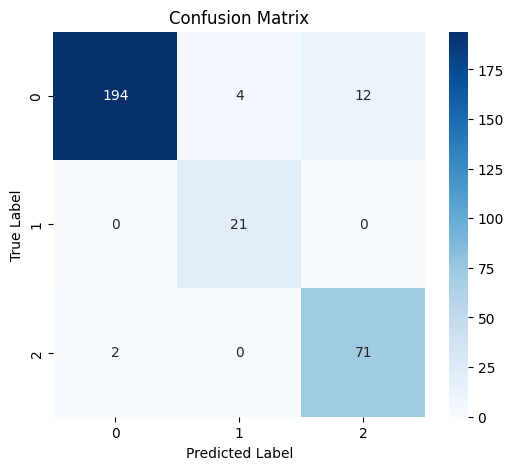

In [47]:
print(classification_report(annotation["Overall"], annotation["model"]))

# 生成混淆矩阵
cm = confusion_matrix(annotation["Overall"], annotation["model"])

# 转换为DataFrame方便显示
cm_df = pd.DataFrame(cm)

# # 打印混淆矩阵
# print("Confusion Matrix:\n", cm_df)

# 可视化
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [50]:
annotation.to_csv('test_for_svm.csv', index=False)

              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92       210
         1.0       0.78      1.00      0.88        21
         2.0       0.75      0.99      0.85        73

    accuracy                           0.90       304
   macro avg       0.84      0.95      0.88       304
weighted avg       0.92      0.90      0.90       304

Confusion Matrix:
      0   1   2
0  180   6  24
1    0  21   0
2    1   0  72


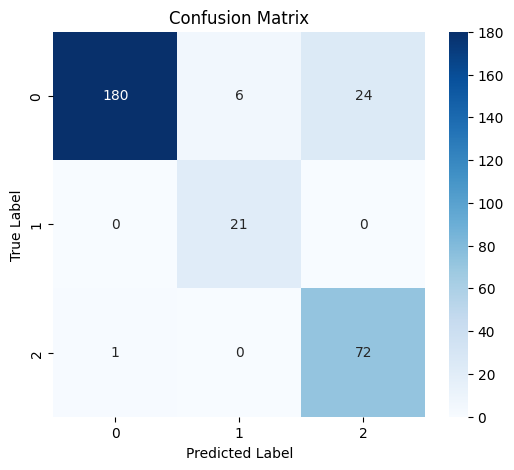

In [37]:
print(classification_report(annotation["Overall"], annotation["model"]))

# 生成混淆矩阵
cm = confusion_matrix(annotation["Overall"], annotation["model"])

# 转换为DataFrame方便显示
cm_df = pd.DataFrame(cm)

# 打印混淆矩阵
print("Confusion Matrix:\n", cm_df)

# 可视化
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [38]:
df5[df5['report_id']==690074201].head(1)

,report_id,standard_drug,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,Prompt,row_idx,response,llm_output,steroid_for_symptom,immunotherapy_hold_for_symptom,intervene_target_symtom
351,690074201,nivolumab,Shortness of Breath,shortness of breath,1561.0,19.0,shortness,sease); DVT (deep venous thrombosis); Essentia...,690074201_1561,patient 15,validation,Patient Note:sease); DVT (deep venous thrombo...,522,"```json\n{\n ""symptom"": ""shortness of breath""...","{'symptom': 'shortness of breath', 'steroid_fo...",False,False,N


In [39]:
annotation[(annotation['model']==2) & (annotation['Overall']==0)]

,report_id,standard_drug,standard_symptom,Overall,m1,m2,m4,m5,drug_negation,symptom_negation,cause_matches_input_drug,intervene_target_symtom,model
13,75298063,ipilimumab,Hypertension,0.0,Y,Y,O,N,Y,Y,O,N,2
19,86297442,ipilimumab,Arthritis,0.0,N,Y,O,N,Y,Y,O,N,2
22,86297442,ipilimumab,Hypertension,0.0,N,Y,O,N,Y,Y,O,N,2
25,88261905,ipilimumab,Abdominal Pain,0.0,N,Y,O,N,Y,Y,O,N,2
26,88261905,ipilimumab,Arthritis,0.0,N,Y,O,N,Y,Y,O,N,2
29,88261905,ipilimumab,Hypertension,0.0,N,Y,O,N,Y,Y,O,N,2
31,88261905,ipilimumab,Pruritus,0.0,N,N,O,N,Y,Y,O,N,2
52,454866485,nivolumab,Diarrhea,0.0,Y,Y,N,N,Y,Y,O,N,2
59,582368542,nivolumab,Back Pain,0.0,Y,N,O,N,Y,Y,O,N,2
62,582368542,nivolumab,Diarrhea,0.0,Y,Y,N,N,Y,Y,O,N,2


In [40]:
df5[(df5['report_id']==686786066)&(df5['standard_drug']=='pembrolizumab')&(df5['standard_symptom']=='Abnormal LFTs')]

,report_id,standard_drug,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,Prompt,row_idx,response,llm_output,steroid_for_symptom,immunotherapy_hold_for_symptom,intervene_target_symtom


In [41]:
df2[(df2['report_id']==70566967)&(df2['standard_drug']=='ipilimumab')&(df2['standard_symptom']=='Adrenal Insufficiency')]

,report_id,standard_drug,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,Prompt,row_idx,response,llm_output,symptom_negation
23593,70566967,ipilimumab,Adrenal Insufficiency,Adrenal insufficiency,8434.0,21.0,Adrenal,back to Onc 1 for further management. 1. Hype...,70566967_8434,patient 32,testing,ipilimumab_70566967_8434,Patient Note: back to Onc 1 for further manag...,745,"```json\n{\n ""step1_extracted_symptom"": ""Adre...",{'step1_extracted_symptom': 'Adrenal insuffici...,N
23594,70566967,ipilimumab,Adrenal Insufficiency,Adrenal insufficiency,10094.0,21.0,Adrenal,back to Onc 1 for further management. 1. Hype...,70566967_10094,patient 32,testing,ipilimumab_70566967_10094,Patient Note: back to Onc 1 for further manag...,746,"```json\n{\n ""step1_extracted_symptom"": ""Adre...",{'step1_extracted_symptom': 'Adrenal insuffici...,N
23595,70566967,ipilimumab,Adrenal Insufficiency,Adrenal insufficiency,12220.0,21.0,Adrenal,back to Onc 1 for further management. 1. Hype...,70566967_12220,patient 32,testing,ipilimumab_70566967_12220,Patient Note: back to Onc 1 for further manag...,747,"```json\n{\n ""step1_extracted_symptom"": ""Adre...",{'step1_extracted_symptom': 'Adrenal insuffici...,N


# Sampling data to annotate

In [8]:
sample_ori = df2[df2['patient_index']!='patient_index'][['report_id', 'patient_index','split']].drop_duplicates()

In [11]:
sampled_df = (
    sample_ori.groupby('patient_index', group_keys=False)
      .apply(lambda x: x.sample(n=2, random_state=42))
)

# reset index if needed
sampled_df = sampled_df.reset_index(drop=True)

/tmp/ipykernel_1363211/3669312557.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2, random_state=42))


In [12]:
sampled_df

,report_id,patient_index,split
0,582368542,patient 1,testing
1,633079529,patient 1,testing
2,690940301,patient 10,training
3,668417467,patient 10,training
4,727245465,patient 11,training
...,...,...,...
87,751633776,patient 7,validation
88,566864634,patient 8,training
89,592189971,patient 8,training
90,454866485,patient 9,testing


In [14]:
sampled_df.to_csv('samples.csv', index=False)

# Merge Tables

In [5]:
df1.rename(columns = {'Prompt':'p1', 'llm_output':'o1'}, inplace=True)
df1 = df1[['report_id', 'standard_drug', 'patient_index', 'drug_adjacent', 'p1','o1']].copy()
df1.head(2)

,report_id,standard_drug,patient_index,drug_adjacent,p1,o1
0,report_id,standard_drug,patient_index,drug_adjacent,Prompt,parse_failed
9,206647850,ipilimumab,patient 6,".0 3/21/13 acth 24, cortisol 30.40 4/22/13 act...","Clinical Note:.0 3/21/13 acth 24, cortisol 30....","{'tagged_drug_text': 'IPILIMUMAB', 'input_drug..."


In [6]:
df2.rename(columns = {'Prompt':'p2', 'llm_output':'o2'}, inplace=True)
df2 = df2[['report_id', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split', 'p2', 'o2']].copy()
df2.head(2)

,report_id,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,p2,o2
0,80740166,Chest Pain,Chest pain,2103.0,10.0,chest,"edical, social, family history since last endo...",80740166_2103,patient 32,testing,"Patient Note:edical, social, family history si...","{'input_drug': 'ipilimumab', 'step1_symptom_lo..."
1,80740166,Dizziness,Dizziness,2369.0,9.0,dizziness,tudy and bi-pap instead of c-pap ROS: General:...,80740166_2369,patient 32,testing,Patient Note:tudy and bi-pap instead of c-pap ...,"{'input_drug': 'ipilimumab', 'step1_symptom_lo..."


In [7]:
df3.rename(columns = {'Prompt':'p3', 'llm_output':'o3'}, inplace=True)
df3 = df3[['report_id', 'standard_drug', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split', 'drug_symptom_id', 'p3', 'o3']].copy()
df3.head(2)

,report_id,standard_drug,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,p3,o3
0,117531472,ipilimumab,Rash,Rash,942.0,4.0,rash,"t_ After her first cycle of ipilimumab, she ha...",117531472_942,patient 32,testing,ipilimumab_117531472_942,Patient Note:t_ After her first cycle of ipil...,"{'step1_extracted_symptom': 'Rash', 'step1_com..."
1,117531472,ipilimumab,Rash,Rash,1015.0,4.0,rash,t ankle and foot with pruritus and pain on pal...,117531472_1015,patient 32,testing,ipilimumab_117531472_1015,Patient Note:t ankle and foot with pruritus a...,"{'step1_extracted_symptom': 'Rash', 'step1_com..."


In [8]:
df4.rename(columns = {'Prompt':'p4', 'llm_output':'o4'}, inplace=True)
df4 = df4[['report_id', 'standard_drug', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split', 'drug_symptom_id', 'p4', 'o4']].copy()
df4.head(2)

,report_id,standard_drug,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,p4,o4
0,126422948,ipilimumab,Adrenal Insufficiency,Adrenal insufficiency,1984.0,21.0,Adrenal,d prior to her 3rd cycle.\n_sent_ She had trea...,126422948_1984,patient 32,testing,ipilimumab_126422948_1984,Patient Note:d prior to her 3rd cycle.\n_sent...,"{'symptom': 'Adrenal insufficiency', 'input_dr..."
1,126422948,ipilimumab,Adrenal Insufficiency,Adrenal insufficiency,4076.0,21.0,Adrenal,tor cuff injury 1998 Right rotator cuff injury...,126422948_4076,patient 32,testing,ipilimumab_126422948_4076,Patient Note:tor cuff injury 1998 Right rotat...,"{'symptom': 'Adrenal insufficiency', 'input_dr..."


In [9]:
df5.rename(columns = {'Prompt':'p5', 'llm_output':'o5'}, inplace=True)
df5 = df5[['report_id', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split', 'p5', 'o5']].copy()
df5.head(2)

,report_id,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,p5,o5
0,117531472,Rash,Rash,942.0,4.0,rash,"t_ After her first cycle of ipilimumab, she ha...",117531472_942,patient 32,testing,Patient Note:t_ After her first cycle of ipil...,{'step_1': {'sentence_containing_symptom': 'Sh...
1,117531472,Rash,Rash,1015.0,4.0,rash,t ankle and foot with pruritus and pain on pal...,117531472_1015,patient 32,testing,Patient Note:t ankle and foot with pruritus a...,{'step_1': {'sentence_containing_symptom': 'Th...


In [10]:
df3.shape

(31590, 14)

In [11]:
df_all = df3.merge(df4, on=['report_id', 'standard_drug', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split', 'drug_symptom_id'], how = 'left')
df_all = df_all.merge(df2, on=['report_id', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split'], how = 'left')
df_all = df_all.merge(df5, on=['report_id', 'standard_symptom', 'matched_variant',
       'start_index', 'variant_length', 'theword', 'symptom_adjacent',
       'symptom_id', 'patient_index', 'split'], how = 'left')

In [12]:
df_all.shape

(31590, 20)

In [13]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31590 entries, 0 to 31589
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   report_id         31590 non-null  object
 1   standard_drug     31590 non-null  object
 2   standard_symptom  31590 non-null  object
 3   matched_variant   31590 non-null  object
 4   start_index       31590 non-null  object
 5   variant_length    31590 non-null  object
 6   theword           31590 non-null  object
 7   symptom_adjacent  31590 non-null  object
 8   symptom_id        31590 non-null  object
 9   patient_index     31590 non-null  object
 10  split             31590 non-null  object
 11  drug_symptom_id   31590 non-null  object
 12  p3                31590 non-null  object
 13  o3                31590 non-null  object
 14  p4                31590 non-null  object
 15  o4                31590 non-null  object
 16  p2                31590 non-null  object
 17  o2          

In [16]:
df_all.sort_values(by = ['split', 'patient_index', 'report_id', 'standard_drug','standard_symptom', 'start_index'], inplace=True)

In [18]:
df_all.to_csv('df_all.csv', index=False)
df1.to_csv('df1.csv', index=False)

In [5]:
# Read all sheets at once
dfs = pd.read_excel("output_27b_detailed.xlsx", sheet_name=None)

# `dfs` is now a dict of DataFrames
# You can access each sheet by its name
for name, df in dfs.items():
    print(f"Sheet: {name}, Shape: {df.shape}")

Sheet: Sheet2, Shape: (746, 5)
Sheet: Sheet1, Shape: (1456, 34)


In [6]:
raw = dfs['Sheet1'].copy()

In [7]:
raw = raw[~raw.isin(['tbd', 'PARSING_ERROR']).any(axis=1)].copy()

In [8]:
raw.columns

Index(['report_id', 'standard_drug', 'llm_output', 'm_drug_negation', 'notes',
       'symptom_adjacent', 'standard_symptom', 'matched_variant', 'symptom_id',
       'patient_index', 'split', 'symtom_negation', 'm_symtom_negation',
       'drug_symptom_id', 'in_amf_format', 'm_in_amf_format', 'amf_result',
       'm_amf_result', 'symptom_has_identified_cause',
       'm_symptom_has_identified_cause', 'cause_matches_input_drug',
       'm_cause_matches_input_drug', 'symptom_severity', 'm_symptom_severity',
       'timing_onset', 'm_timing_onset', 'physician_assessment',
       'other_details', 'intervene_found', 'm_intervene_found',
       'intervene_target_symtom', 'm_intervene_target_symtom', 'Model',
       'Label'],
      dtype='object')

In [9]:
raw = raw[['report_id', 'standard_drug', 'm_drug_negation', 'standard_symptom', 'symptom_id',
       'patient_index', 'm_symtom_negation',
       'drug_symptom_id', 'm_in_amf_format', 
       'm_amf_result', 
       'm_symptom_has_identified_cause', 
       'm_cause_matches_input_drug', 'm_intervene_found',
 'm_intervene_target_symtom', 
       'Label']].copy()

In [10]:
raw['drug_symptom_id'] = raw.apply(lambda x: x['standard_drug'] + '_' + x['symptom_id'], axis=1)

# df1

In [11]:
df1[df1['llm_output']=='parse_failed']

,idx,report_id,notes,standard_drug,drug_adjacent,patient_index,Prompt,row_idx,response,llm_output
10,idx,report_id,notes,standard_drug,drug_adjacent,patient_index,Prompt,row_idx,response,parse_failed
28,126,655719206,note_date [**2016-10-19**]\n_sent_ Interval Hi...,nivolumab,"lung cancer.\n_sent_ EGFR, ALK, ROS, RET, MET...",patient 24,"Clinical Note: lung cancer.\n_sent_ EGFR, ALK,...",126,"```json\n{\n ""tagged_drug_text"": "" NIVOLUMAB ...",parse_failed
191,375,751664786,980261146 7/21/17 751664786the james comprehen...,ipilimumab,lanoma -she underwent wide-excision and sentin...,patient 40,Clinical Note:lanoma -she underwent wide-excis...,375,"```json\n{\n ""tagged_drug_text"": ""IPILIMUMAB""...",parse_failed
204,387,767482953,980261146 9/11/17 767482953the james comprehen...,ipilimumab,lanoma -she underwent wide-excision and sentin...,patient 40,Clinical Note:lanoma -she underwent wide-excis...,387,"```json\n{\n ""tagged_drug_text"": ""IPILIMUMAB""...",parse_failed
225,407,795087734,980261146 11/27/17 795087734the james comprehe...,ipilimumab,lanoma -she underwent wide-excision and sentin...,patient 40,Clinical Note:lanoma -she underwent wide-excis...,407,"```json\n{\n ""tagged_drug_text"": ""IPILIMUMAB""...",parse_failed
236,417,812663424,980261146 1/22/18 812663424the james comprehen...,ipilimumab,lanoma -she underwent wide-excision and sentin...,patient 40,Clinical Note:lanoma -she underwent wide-excis...,417,"```json\n{\n ""tagged_drug_text"": ""IPILIMUMAB""...",parse_failed
363,298,735503728,980261146 6/9/17 735503728clinic note chief co...,ipilimumab,melanoma with final negative margins.\nintraop...,patient 40,Clinical Note:melanoma with final negative mar...,298,<unused94>thought\nThe user wants me to analyz...,parse_failed
426,56,588397690,note_date [**2016-03-17**]\nCLINIC NOTE: [**Kn...,nivolumab,*]: FNA confirmed metastatic melanoma.\nHis pr...,patient 31,Clinical Note:*]: FNA confirmed metastatic mel...,56,<unused94>thought\nThe user wants me to analyz...,parse_failed


In [12]:
df1['llm_output'].iloc[0]

{'tagged_drug_text': 'NIVOLUMAB',
 'input_drug': 'nivolumab',
 'step_2_drug_match': 'DRUG MATCH',
 'step_2_reasoning': 'Exact match',
 'step_3_drug_exposure': 'Confirmed',
 'step_3_reasoning': 'Note indicates patient is tolerating the drug',
 'step_4_initiated_today': 'No',
 'step_4_reasoning': 'Note indicates patient was cleared for the drug today as part of an ongoing cycle (C13D1), implying prior administration.',
 'final_conclusion': 'Patient received nivolumab, but it was not initiated today.',
 'relevant_sentence': '[**Doctor Last Name **] appears to be tolerating <drug> NIVOLUMAB </drug> well apart from grade 1 rash, mouth pain.'}

In [13]:
df1['drug_negation'] = df1['llm_output'].apply(lambda x: x['step_3_drug_exposure'] if x!='parse_failed' else x)
# df1['drug_exposure'] = df1['llm_output'].apply(lambda x: x['step_3_drug_exposure'] if x!='parse_failed' else x)
# df1['initoday'] = df1['llm_output'].apply(lambda x: x['step_4_initiated_today'] if x!='parse_failed' else x)
# df1['drug_negation'] = df1.apply(lambda x: 'Confirmed' if x['drug_exposure']=='Confirmed' and x['initoday'].strip().lower()=='no' else 'NC', axis=1)

In [14]:
df1

,idx,report_id,notes,standard_drug,drug_adjacent,patient_index,Prompt,row_idx,response,llm_output,drug_negation
0,100,642083207,note_date [**2016-08-18**]\nCLINIC NOTE: [**Kn...,nivolumab,] [**Known patient firstname 3**] Jr. is a 84 ...,patient 31,Clinical Note:] [**Known patient firstname 3**...,100,"```json\n{\n ""tagged_drug_text"": ""NIVOLUMAB"",...","{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Confirmed
1,101,642083207,note_date [**2016-08-18**]\nCLINIC NOTE: [**Kn...,nivolumab,onfirmed metastatic melanoma.\nHis primary tum...,patient 31,Clinical Note:onfirmed metastatic melanoma.\nH...,101,"```json\n{\n ""tagged_drug_text"": ""NIVOLUMAB"",...","{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Confirmed
2,102,642083207,note_date [**2016-08-18**]\nCLINIC NOTE: [**Kn...,nivolumab,Name **] is following with cardiology.\n- MRI ...,patient 31,Clinical Note:Name **] is following with cardi...,102,"```json\n{\n ""tagged_drug_text"": "" NIVOLUMAB ...","{'tagged_drug_text': ' NIVOLUMAB ', 'input_dru...",Vague
3,103,642083207,note_date [**2016-08-18**]\nCLINIC NOTE: [**Kn...,nivolumab,take 1 tablet by mouth daily.\nloperamide 2 M...,patient 31,Clinical Note: take 1 tablet by mouth daily.\n...,103,"```json\n{\n ""tagged_drug_text"": ""OPDIVO"",\n ...","{'tagged_drug_text': 'OPDIVO', 'input_drug': '...",Confirmed
4,104,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,left ischium.\n_sent_ New focal radiotracer u...,patient 24,Clinical Note: left ischium.\n_sent_ New focal...,104,"```json\n{\n ""tagged_drug_text"": "" NIVOLUMAB ...","{'tagged_drug_text': ' NIVOLUMAB ', 'input_dru...",Confirmed
...,...,...,...,...,...,...,...,...,...,...,...
469,95,641828005,note_date [**2016-08-26**]\n_sent_ [**Telephon...,nivolumab,6 weeks.\n_sent_ We discussed following good b...,patient 24,Clinical Note:6 weeks.\n_sent_ We discussed fo...,95,"```json\n{\n ""tagged_drug_text"": ""Nivo"",\n ""...","{'tagged_drug_text': 'Nivo', 'input_drug': 'ni...",Confirmed
470,96,641828005,note_date [**2016-08-26**]\n_sent_ [**Telephon...,nivolumab,6 weeks.\n_sent_ We discussed following good b...,patient 24,Clinical Note:6 weeks.\n_sent_ We discussed fo...,96,"```json\n{\n ""tagged_drug_text"": ""Nivo"",\n ""...","{'tagged_drug_text': 'Nivo', 'input_drug': 'ni...",Confirmed
471,97,641831672,note_date [**2016-08-25**]\n_sent_ Department ...,nivolumab,note_date [**2016-08-25**]\n_sent_ Department ...,patient 24,Clinical Note:note_date [**2016-08-25**]\n_sen...,97,"```json\n{\n ""tagged_drug_text"": ""NIVOLUMAB"",...","{'tagged_drug_text': 'NIVOLUMAB', 'input_drug'...",Vague
472,98,642083207,note_date [**2016-08-18**]\nCLINIC NOTE: [**Kn...,nivolumab,"ctor Last Name 5**] had a severe ""dizzy feelin...",patient 31,Clinical Note:ctor Last Name 5**] had a severe...,98,"```json\n{\n ""tagged_drug_text"": "" NIVOLUMAB ...","{'tagged_drug_text': ' NIVOLUMAB ', 'input_dru...",Vague


In [15]:
df1.columns

Index(['idx', 'report_id', 'notes', 'standard_drug', 'drug_adjacent',
       'patient_index', 'Prompt', 'row_idx', 'response', 'llm_output',
       'drug_negation'],
      dtype='object')

In [16]:
df1 = df1[['report_id', 'notes', 'standard_drug', 'drug_adjacent','patient_index', 'drug_negation','llm_output']].copy()

In [17]:
df1.drug_negation.unique()

array(['Confirmed', 'Vague', 'parse_failed', 'Denied'], dtype=object)

In [18]:
# df_grouped = df1.groupby(['report_id', 'standard_drug'], as_index=False).agg(
#     {'drug_negation':lambda x: 0 if "DRUG TAKEN" in x.values else 1}
# )

df_grouped = df1.groupby(['report_id', 'standard_drug'], as_index=False).agg(
    {'drug_negation':lambda x: 0 if "Confirmed" in x.values else 1}
)

In [19]:
df_grouped

,report_id,standard_drug,drug_negation
0,476169085,ipilimumab,1
1,476231018,ipilimumab,1
2,501075426,nivolumab,0
3,501085236,nivolumab,0
4,503238928,ipilimumab,1
...,...,...,...
87,778052396,ipilimumab,0
88,795087734,ipilimumab,0
89,812663424,ipilimumab,0
90,853617578,ipilimumab,0


In [20]:
raw['report_id'] = raw['report_id'].astype(str)

In [21]:
raw = raw.merge(df_grouped, on=['report_id', 'standard_drug'], how='left')

In [22]:
raw

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation
0,641828005,nivolumab,1,Abdominal Pain,641828005_1230,patient 24,1,nivolumab_641828005_1230,0.0,0.0,0,0,0.0,0,0,0
1,641828005,nivolumab,1,Abdominal Pain,641828005_10313,patient 24,1,nivolumab_641828005_10313,0.0,0.0,0,0,0.0,0,0,0
2,641828005,nivolumab,1,Diarrhea,641828005_668,patient 24,0,nivolumab_641828005_668,0.0,0.0,1,0,0.0,0,0,0
3,641828005,nivolumab,1,Diarrhea,641828005_9751,patient 24,0,nivolumab_641828005_9751,0.0,0.0,1,0,0.0,0,0,0
4,641828005,nivolumab,1,Numbness,641828005_1246,patient 24,1,nivolumab_641828005_1246,0.0,0.0,0,0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,853617578,ipilimumab,0,Hypothyroid,853617578_8846,patient 40,0,ipilimumab_853617578_8846,0.0,0.0,0,0,NaN,0,2,0
1297,853617578,ipilimumab,0,Numbness,853617578_7155,patient 40,1,ipilimumab_853617578_7155,0.0,0.0,0,0,NaN,0,0,0
1298,853617578,ipilimumab,0,Shortness of Breath,853617578_7042,patient 40,1,ipilimumab_853617578_7042,0.0,0.0,0,0,NaN,0,0,0
1299,853617578,ipilimumab,0,Shortness of Breath,853617578_6979,patient 40,1,ipilimumab_853617578_6979,0.0,0.0,0,0,NaN,0,0,0


In [23]:
odf1 = raw.groupby(['report_id', 'standard_drug'], as_index=False).agg({'m_drug_negation':'mean', 'drug_negation':'mean'})

In [24]:
print(classification_report(odf1["m_drug_negation"], odf1["drug_negation"]))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97        69
         1.0       0.94      0.84      0.89        19

    accuracy                           0.95        88
   macro avg       0.95      0.91      0.93        88
weighted avg       0.95      0.95      0.95        88



In [25]:
odf1[odf1['drug_negation']!=odf1['m_drug_negation']]

,report_id,standard_drug,m_drug_negation,drug_negation
20,613897387,ipilimumab,1.0,0.0
24,641828005,nivolumab,1.0,0.0
53,714849544,ipilimumab,1.0,0.0
64,740874328,nivolumab,0.0,1.0


In [26]:
df1[df1['report_id']=='613897387'].iloc[0]['llm_output']

{'tagged_drug_text': 'IPILIMUMAB',
 'input_drug': 'ipilimumab',
 'step_2_drug_match': 'DRUG MATCH',
 'step_2_reasoning': 'The tagged text is the input drug itself (case-insensitive).',
 'step_3_drug_exposure': 'Confirmed',
 'step_3_reasoning': 'The note states the patient is on a study involving the drug and lists past dose dates.',
 'step_4_initiated_today': 'No',
 'step_4_reasoning': 'The note indicates past administration (last dose 3/16/2015) and the patient is in clinic for follow-up, not initiation.',
 'final_conclusion': 'The patient received ipilimumab in the past as part of a research study, but it was not initiated today.',
 'relevant_sentence': 'stephanie r casino is on research study ecog-e1609: a phase iii randomized study of adjuvant <drug> IPILIMUMAB </drug> anti-ctla4 therapy versus high-dose interferon -2b for resected high-risk melanoma.'}

# df2

In [27]:
df2[df2['llm_output']=='parse_failed']

,report_id,notes,standard_drug,drug_adjacent,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,Prompt,row_idx,response,llm_output
10,report_id,notes,standard_drug,drug_adjacent,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,Prompt,row_idx,response,parse_failed
1341,681628913,980261146 12/27/16 681628913stephanie r casino...,ipilimumab,['atible with an intransit metastasis of malig...,Erythema,erythema,1732.0,8.0,erythema,gins.\nintraoperative lymphatic mapping reveal...,681628913_1732,patient 40,validation,ipilimumab_681628913_1732,Patient Note:gins.\nintraoperative lymphatic ...,881,<unused94>thought\nThe user wants me to analyz...,parse_failed


In [28]:
df2['llm_output'][0]

{'step1_extracted_symptom': 'diarrhea',
 'step1_complete_sentence': '_sent_ Negative for <symptom> diarrhea </symptom>, blood in stool, or melena.',
 'step2_analysis': {'label': 'NO CLEAR EVIDENCE OF SYMPTOM IN PATIENT',
  'reasoning': "The sentence explicitly states 'Negative for diarrhea', indicating the patient denies this symptom. This falls under the 'Explicit Negation' category."},
 'summary': "The symptom 'diarrhea' is explicitly denied by the patient."}

In [29]:
df2['symptom_negation'] = df2['llm_output'].apply(lambda x: x['step2_analysis']['label'] if x!='parse_failed' else x)
df2['symptom_negation'] = df2['symptom_negation'].apply(lambda x: 1 if x=='NO CLEAR EVIDENCE OF SYMPTOM IN PATIENT' else 0)

In [30]:
df2

,report_id,notes,standard_drug,drug_adjacent,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id,Prompt,row_idx,response,llm_output,symptom_negation
0,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,[' left ischium.\n_sent_ New focal radiotracer...,Diarrhea,diarrhea,13147.0,8.0,diarrhea,"er, or chills.\n_sent_ PS = 0 Skin:Negative fo...",647369991_13147,patient 24,validation,nivolumab_647369991_13147,"Patient Note:er, or chills.\n_sent_ PS = 0 Sk...",600,"```json\n{\n ""step1_extracted_symptom"": ""diar...","{'step1_extracted_symptom': 'diarrhea', 'step1...",1
1,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,[' left ischium.\n_sent_ New focal radiotracer...,Diarrhea,diarrhea,37736.0,8.0,Diarrhea,atus Relation Status Mother Deceased Father De...,647369991_37736,patient 24,validation,nivolumab_647369991_37736,Patient Note:atus Relation Status Mother Dece...,601,"```json\n{\n ""step1_extracted_symptom"": ""diar...","{'step1_extracted_symptom': 'diarrhea', 'step1...",0
2,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,[' left ischium.\n_sent_ New focal radiotracer...,Diarrhea,diarrhea,40005.0,8.0,diarrhea,"er, or chills.\n_sent_ PS = 0 Skin:Negative fo...",647369991_40005,patient 24,validation,nivolumab_647369991_40005,"Patient Note:er, or chills.\n_sent_ PS = 0 Sk...",602,"```json\n{\n ""step1_extracted_symptom"": ""diar...","{'step1_extracted_symptom': 'diarrhea', 'step1...",1
3,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,[' left ischium.\n_sent_ New focal radiotracer...,Diabetes,DIABETES,10269.0,8.0,Diabetes,cluded Cigarettes.\n_sent_ [**Doctor Last Name...,647369991_10269,patient 24,validation,nivolumab_647369991_10269,Patient Note:cluded Cigarettes.\n_sent_ [**Do...,603,"```json\n{\n ""step1_extracted_symptom"": ""DIAB...","{'step1_extracted_symptom': 'DIABETES', 'step1...",1
4,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,[' left ischium.\n_sent_ New focal radiotracer...,Diabetes,DIABETES,37127.0,8.0,Diabetes,cluded Cigarettes.\n_sent_ [**Doctor Last Name...,647369991_37127,patient 24,validation,nivolumab_647369991_37127,Patient Note:cluded Cigarettes.\n_sent_ [**Do...,604,"```json\n{\n ""step1_extracted_symptom"": ""DIAB...","{'step1_extracted_symptom': 'DIABETES', 'step1...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2268,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Hypothyroid,hypothyroidism,15918.0,14.0,hypothyroidism,er at length.\n- c3 ipilimumab was delayed 1 w...,742730480_15918,patient 40,validation,ipilimumab_742730480_15918,Patient Note:er at length.\n- c3 ipilimumab w...,1195,"```json\n{\n ""step1_extracted_symptom"": ""hypo...","{'step1_extracted_symptom': 'hypothyroidism', ...",0
2269,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Hypothyroid,hypothyroidism,16138.0,14.0,hypothyroidism,"weeks labs (cbc, cmp, ldh, tsh, ft4, acth, cor...",742730480_16138,patient 40,validation,ipilimumab_742730480_16138,"Patient Note:weeks labs (cbc, cmp, ldh, tsh, ...",1196,"```json\n{\n ""step1_extracted_symptom"": ""hypo...","{'step1_extracted_symptom': 'hypothyroidism', ...",1
2270,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Transaminitis,transaminitis,2553.0,13.0,transaminitis,ad an fna was done that was positive for metas...,742730480_2553,patient 40,validation,ipilimumab_742730480_2553,Patient Note:ad an fna was done that was posi...,1197,"```json\n{\n ""step1_extracted_symptom"": ""tran...","{'step1_extracted_symptom': 'transaminitis', '...",0
2271,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit n

In [31]:
df2 = df2[['report_id', 'notes', 'standard_drug','standard_symptom', 'symptom_adjacent', 'symptom_id', 'drug_symptom_id', 'symptom_negation','llm_output']].copy()

In [32]:
df2

,report_id,notes,standard_drug,standard_symptom,symptom_adjacent,symptom_id,drug_symptom_id,symptom_negation,llm_output
0,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,Diarrhea,"er, or chills.\n_sent_ PS = 0 Skin:Negative fo...",647369991_13147,nivolumab_647369991_13147,1,"{'step1_extracted_symptom': 'diarrhea', 'step1..."
1,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,Diarrhea,atus Relation Status Mother Deceased Father De...,647369991_37736,nivolumab_647369991_37736,0,"{'step1_extracted_symptom': 'diarrhea', 'step1..."
2,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,Diarrhea,"er, or chills.\n_sent_ PS = 0 Skin:Negative fo...",647369991_40005,nivolumab_647369991_40005,1,"{'step1_extracted_symptom': 'diarrhea', 'step1..."
3,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,Diabetes,cluded Cigarettes.\n_sent_ [**Doctor Last Name...,647369991_10269,nivolumab_647369991_10269,1,"{'step1_extracted_symptom': 'DIABETES', 'step1..."
4,647369991,note_date [**2016-09-26**]\n_sent_ [**Telephon...,nivolumab,Diabetes,cluded Cigarettes.\n_sent_ [**Doctor Last Name...,647369991_37127,nivolumab_647369991_37127,1,"{'step1_extracted_symptom': 'DIABETES', 'step1..."
...,...,...,...,...,...,...,...,...,...
2268,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,Hypothyroid,er at length.\n- c3 ipilimumab was delayed 1 w...,742730480_15918,ipilimumab_742730480_15918,0,"{'step1_extracted_symptom': 'hypothyroidism', ..."
2269,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,Hypothyroid,"weeks labs (cbc, cmp, ldh, tsh, ft4, acth, cor...",742730480_16138,ipilimumab_742730480_16138,1,"{'step1_extracted_symptom': 'hypothyroidism', ..."
2270,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,Transaminitis,ad an fna was done that was positive for metas...,742730480_2553,ipilimumab_742730480_2553,0,"{'step1_extracted_symptom': 'transaminitis', '..."
2271,742730480,980261146 6/28/17 742730480clinic note chief c...,ipilimumab,Transaminitis,ant ifn 03/17/2014 c1d1 hd-ifn (20 mu/m2) per ...,742730480_3448,ipilimumab_742730480_3448,0,"{'step1_extracted_symptom': 'transaminitis', '..."


In [33]:
# df_grouped = df2.groupby(['report_id', 'standard_drug', 'standard_symptom'], as_index=False).agg(
#     {'symptom_negation':lambda x: 0 if "SYMPTOM PRESENT IN PATIENT" in x.values else 1}
# )

df_grouped = df2[['symptom_id', 'symptom_negation']].drop_duplicates()

In [34]:
df_grouped

,symptom_id,symptom_negation
0,647369991_13147,1
1,647369991_37736,0
2,647369991_40005,1
3,647369991_10269,1
4,647369991_37127,1
...,...,...
2268,742730480_15918,0
2269,742730480_16138,1
2270,742730480_2553,0
2271,742730480_3448,0


In [35]:
df_grouped

,symptom_id,symptom_negation
0,647369991_13147,1
1,647369991_37736,0
2,647369991_40005,1
3,647369991_10269,1
4,647369991_37127,1
...,...,...
2268,742730480_15918,0
2269,742730480_16138,1
2270,742730480_2553,0
2271,742730480_3448,0


In [36]:
raw

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation
0,641828005,nivolumab,1,Abdominal Pain,641828005_1230,patient 24,1,nivolumab_641828005_1230,0.0,0.0,0,0,0.0,0,0,0
1,641828005,nivolumab,1,Abdominal Pain,641828005_10313,patient 24,1,nivolumab_641828005_10313,0.0,0.0,0,0,0.0,0,0,0
2,641828005,nivolumab,1,Diarrhea,641828005_668,patient 24,0,nivolumab_641828005_668,0.0,0.0,1,0,0.0,0,0,0
3,641828005,nivolumab,1,Diarrhea,641828005_9751,patient 24,0,nivolumab_641828005_9751,0.0,0.0,1,0,0.0,0,0,0
4,641828005,nivolumab,1,Numbness,641828005_1246,patient 24,1,nivolumab_641828005_1246,0.0,0.0,0,0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,853617578,ipilimumab,0,Hypothyroid,853617578_8846,patient 40,0,ipilimumab_853617578_8846,0.0,0.0,0,0,NaN,0,2,0
1297,853617578,ipilimumab,0,Numbness,853617578_7155,patient 40,1,ipilimumab_853617578_7155,0.0,0.0,0,0,NaN,0,0,0
1298,853617578,ipilimumab,0,Shortness of Breath,853617578_7042,patient 40,1,ipilimumab_853617578_7042,0.0,0.0,0,0,NaN,0,0,0
1299,853617578,ipilimumab,0,Shortness of Breath,853617578_6979,patient 40,1,ipilimumab_853617578_6979,0.0,0.0,0,0,NaN,0,0,0


In [37]:
# odf2['report_id'] = odf2['report_id'].astype(str)
raw = raw.merge(df_grouped, on=['symptom_id'], how='left')

In [38]:
raw

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation,symptom_negation
0,641828005,nivolumab,1,Abdominal Pain,641828005_1230,patient 24,1,nivolumab_641828005_1230,0.0,0.0,0,0,0.0,0,0,0,1
1,641828005,nivolumab,1,Abdominal Pain,641828005_10313,patient 24,1,nivolumab_641828005_10313,0.0,0.0,0,0,0.0,0,0,0,1
2,641828005,nivolumab,1,Diarrhea,641828005_668,patient 24,0,nivolumab_641828005_668,0.0,0.0,1,0,0.0,0,0,0,0
3,641828005,nivolumab,1,Diarrhea,641828005_9751,patient 24,0,nivolumab_641828005_9751,0.0,0.0,1,0,0.0,0,0,0,0
4,641828005,nivolumab,1,Numbness,641828005_1246,patient 24,1,nivolumab_641828005_1246,0.0,0.0,0,0,0.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,853617578,ipilimumab,0,Hypothyroid,853617578_8846,patient 40,0,ipilimumab_853617578_8846,0.0,0.0,0,0,NaN,0,2,0,0
1297,853617578,ipilimumab,0,Numbness,853617578_7155,patient 40,1,ipilimumab_853617578_7155,0.0,0.0,0,0,NaN,0,0,0,1
1298,853617578,ipilimumab,0,Shortness of Breath,853617578_7042,patient 40,1,ipilimumab_853617578_7042,0.0,0.0,0,0,NaN,0,0,0,1
1299,853617578,ipilimumab,0,Shortness of Breath,853617578_6979,patient 40,1,ipilimumab_853617578_6979,0.0,0.0,0,0,NaN,0,0,0,1


In [39]:
raw["m_symtom_negation"] = raw["m_symtom_negation"].astype(int)
raw["m_symtom_negation"].unique()

array([1, 0])

In [40]:
raw["symptom_negation"].unique()

array([1, 0])

In [41]:
print(classification_report(raw["m_symtom_negation"], raw["symptom_negation"]))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       727
           1       0.92      0.98      0.95       574

    accuracy                           0.95      1301
   macro avg       0.95      0.96      0.95      1301
weighted avg       0.96      0.95      0.95      1301



In [42]:
raw[raw['symptom_negation']!=raw['m_symtom_negation']]#.shape

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation,symptom_negation
32,647369991,nivolumab,0,Diabetes,647369991_10269,patient 24,0,nivolumab_647369991_10269,0.0,0.0,0,0,0.0,0,2,0,1
33,647369991,nivolumab,0,Diabetes,647369991_37127,patient 24,0,nivolumab_647369991_37127,0.0,0.0,0,0,0.0,0,2,0,1
50,647369991,nivolumab,0,Edema,647369991_54967,patient 24,0,nivolumab_647369991_54967,0.0,0.0,0,0,0.0,0,0,0,1
57,647369991,nivolumab,0,Fibrosis,647369991_21871,patient 24,0,nivolumab_647369991_21871,0.0,0.0,0,0,0.0,0,2,0,1
58,647369991,nivolumab,0,Fibrosis,647369991_48729,patient 24,0,nivolumab_647369991_48729,0.0,0.0,0,0,0.0,0,2,0,1
73,649289657,nivolumab,0,Fatigue,649289657_8150,patient 24,0,nivolumab_649289657_8150,0.0,0.0,1,1,0.0,0,1,0,1
105,652307472,nivolumab,0,Fatigue,652307472_10351,patient 24,0,nivolumab_652307472_10351,0.0,0.0,1,0,NaN,0,2,0,1
113,655719206,nivolumab,0,Diarrhea,655719206_3264,patient 24,0,nivolumab_655719206_3264,0.0,0.0,0,0,NaN,1,1,0,1
150,668258602,nivolumab,0,Cough,668258602_8604,patient 24,1,nivolumab_668258602_8604,0.0,0.0,0,0,NaN,0,0,0,0
151,668258602,nivolumab,0,Cough,668258602_8662,patient 24,1,nivolumab_668258602_8662,0.0,0.0,0,0,NaN,0,0,0,0


# df3

In [43]:
df3['in_amf_format'] = df3.apply(lambda x: x['llm_output']['final_determination']['structured_format_found'] if x['llm_output']!='parse_failed' else 'PARSING_ERROR', axis=1)
df3['in_amf_format'] = df3['in_amf_format'].apply(lambda x: 0 if x==False else 1)
# df3['amf_result'] = df3.apply(lambda x: x['llm_output']['final_determination']['analysis_result'] if x['llm_output']!='parse_failed' else 'PARSING_ERROR', axis=1)
df3['drug_symptom_id'] = df3.apply(lambda x: x['standard_drug'] + '_' + x['symptom_id'], axis=1)

In [44]:
df3

,report_id,notes,standard_drug,drug_adjacent,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,Prompt,row_idx,response,llm_output,in_amf_format,drug_symptom_id
0,683111148,note_date [**2017-02-03**]\n_sent_ [**Telephon...,nivolumab,"[""note_date [**2017-02-03**]\n_sent_ [**Teleph...",Diarrhea,diarrhea,8849.0,8.0,diarrhea,ast Name 6**] is receiving 100mg of Prednisone...,683111148_8849,patient 24,validation,Patient Note:ast Name 6**] is receiving 100mg ...,900,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_683111148_8849
1,683111148,note_date [**2017-02-03**]\n_sent_ [**Telephon...,nivolumab,"[""note_date [**2017-02-03**]\n_sent_ [**Teleph...",Diarrhea,diarrhea,10594.0,8.0,diarrhea,*Last Name (STitle) 7**].\n_sent_ Chief Compla...,683111148_10594,patient 24,validation,Patient Note:*Last Name (STitle) 7**].\n_sent_...,901,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_683111148_10594
2,683111148,note_date [**2017-02-03**]\n_sent_ [**Telephon...,nivolumab,"[""note_date [**2017-02-03**]\n_sent_ [**Teleph...",Diarrhea,diarrhea,10615.0,8.0,diarrhea,**].\n_sent_ Chief Complaint Patient presents ...,683111148_10615,patient 24,validation,Patient Note:**].\n_sent_ Chief Complaint Pati...,902,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_683111148_10615
3,683111148,note_date [**2017-02-03**]\n_sent_ [**Telephon...,nivolumab,"[""note_date [**2017-02-03**]\n_sent_ [**Teleph...",Diarrhea,diarrhea,10820.0,8.0,diarrhea,ry of Present Illness Mr. [**Initials (NamePat...,683111148_10820,patient 24,validation,Patient Note:ry of Present Illness Mr. [**Init...,903,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_683111148_10820
4,683111148,note_date [**2017-02-03**]\n_sent_ [**Telephon...,nivolumab,"[""note_date [**2017-02-03**]\n_sent_ [**Teleph...",Diarrhea,diarrhea,11167.0,8.0,diarrhea,[**Doctor Last Name 6**] presents today for ev...,683111148_11167,patient 24,validation,Patient Note:[**Doctor Last Name 6**] presents...,904,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_683111148_11167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,735158213,note_date [**2017-07-09**]\n_sent_ [**Telephon...,nivolumab,['note_date [**2017-07-09**]\n_sent_ [**Teleph...,Edema,edema,8462.0,5.0,edema,\n_sent_ No oral lesions or thrush.\n_sent_ Ne...,735158213_8462,patient 24,validation,Patient Note:\n_sent_ No oral lesions or thrus...,1095,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_735158213_8462
1874,735158213,note_date [**2017-07-09**]\n_sent_ [**Telephon...,nivolumab,['note_date [**2017-07-09**]\n_sent_ [**Teleph...,Edema,edema,10780.0,5.0,edema,"s, which improved on 100 mg/d prednisone, slow...",735158213_10780,patient 24,validation,"Patient Note:s, which improved on 100 mg/d pre...",1096,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_735158213_10780
1875,735158213,note_date [**2017-07-09**]\n_sent_ [**Telephon...,nivolumab,['note_date [**2017-07-09**]\n_sent_ [**Teleph...,Edema,edema,10835.0,5.0,edema,"d, now on 10 mg/d.\n_sent_ [**Doctor Last Name...",735158213_10835,patient 24,validation,"Patient Note:d, now on 10 mg/d.\n_sent_ [**Doc...",1097,"```json\n{\n ""input_drug"": ""nivolumab"",\n ""s...","{'input_drug': 'nivolumab', 'step1_symptom_loc...",0,nivolumab_735158213_10835
1876,735158213,note_date [**2017-07-09**]\n_sent_ [**Telephon...,nivolumab,['note_date [**2017-07-09**]\n_sent_ [**Teleph...,Edema,edema,19392.0,5.0,edema,\n_sent_ No oral lesions or thrus

In [45]:
df_grouped = df3[['drug_symptom_id', 'in_amf_format']].drop_duplicates()

In [46]:
raw = raw.merge(df_grouped, on=['drug_symptom_id'], how='left')
raw['m_in_amf_format'] = raw['m_in_amf_format'].astype(int)

In [47]:
raw

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation,symptom_negation,in_amf_format
0,641828005,nivolumab,1,Abdominal Pain,641828005_1230,patient 24,1,nivolumab_641828005_1230,0,0.0,0,0,0.0,0,0,0,1,0
1,641828005,nivolumab,1,Abdominal Pain,641828005_10313,patient 24,1,nivolumab_641828005_10313,0,0.0,0,0,0.0,0,0,0,1,0
2,641828005,nivolumab,1,Diarrhea,641828005_668,patient 24,0,nivolumab_641828005_668,0,0.0,1,0,0.0,0,0,0,0,0
3,641828005,nivolumab,1,Diarrhea,641828005_9751,patient 24,0,nivolumab_641828005_9751,0,0.0,1,0,0.0,0,0,0,0,0
4,641828005,nivolumab,1,Numbness,641828005_1246,patient 24,1,nivolumab_641828005_1246,0,0.0,0,0,0.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,853617578,ipilimumab,0,Hypothyroid,853617578_8846,patient 40,0,ipilimumab_853617578_8846,0,0.0,0,0,NaN,0,2,0,0,0
1297,853617578,ipilimumab,0,Numbness,853617578_7155,patient 40,1,ipilimumab_853617578_7155,0,0.0,0,0,NaN,0,0,0,1,0
1298,853617578,ipilimumab,0,Shortness of Breath,853617578_7042,patient 40,1,ipilimumab_853617578_7042,0,0.0,0,0,NaN,0,0,0,1,0
1299,853617578,ipilimumab,0,Shortness of Breath,853617578_6979,patient 40,1,ipilimumab_853617578_6979,0,0.0,0,0,NaN,0,0,0,1,0


In [48]:
print(classification_report(raw["m_in_amf_format"], raw["in_amf_format"]))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1295
           1       0.24      1.00      0.39         6

    accuracy                           0.99      1301
   macro avg       0.62      0.99      0.69      1301
weighted avg       1.00      0.99      0.99      1301



# df4

In [49]:
df4['llm_output'].iloc[0]

{'symptom': 'diarrhea',
 'input_drug': 'nivolumab',
 'etiology_classification': 'highly_suspect_drug_related',
 'supporting_evidence': 'Secondary to immunotherapy for his lung cancer - his <symptom> diarrhea </symptom> has actually worsened since last dose of Nivolumab.',
 'reasoning': 'The clinical note explicitly links the worsening of diarrhea to the administration of Nivolumab.'}

In [50]:
# df4['symptom_has_identified_cause'] = df4['llm_output'].apply(lambda x: x['step3_causality_analysis']['cause_identified'] if x!='parse_failed' else 'PARSING_ERROR')
# df4['cause_matches_input_drug'] = df4['llm_output'].apply(lambda x: x['step4_drug_attribution']['cause_matches_input_drug'] if x!='parse_failed' else 'PARSING_ERROR')

# df4['symptom_has_identified_cause'] = df4['llm_output'].apply(lambda x: x['step_2']['etiology_status'] if x!='parse_failed' else 'PARSING_ERROR')
# df4['cause_matches_input_drug'] = df4['llm_output'].apply(lambda x: x['step_3']['drug_attribution'] if x!='parse_failed' else 'PARSING_ERROR')

# df4['symptom_has_identified_cause'] = df4['llm_output'].apply(lambda x: x['step_2']['etiology_status'] if x!='parse_failed' else 'PARSING_ERROR')
df4['cause_matches_input_drug'] = df4['llm_output'].apply(lambda x: x['etiology_classification'] if x!='parse_failed' else 'PARSING_ERROR')
 

In [51]:
# df4['symptom_has_identified_cause'].unique()

In [52]:
df4['cause_matches_input_drug'].unique()

array(['highly_suspect_drug_related', 'other', 'PARSING_ERROR',
       'highly_suspect_other_etiology'], dtype=object)

In [53]:
# df4[df4['cause_matches_input_drug'] == 'NA']

In [54]:
# df4['symptom_has_identified_cause'] = df4['symptom_has_identified_cause'].apply(lambda x: 1 if x==True else 0)
# df4['cause_matches_input_drug'] = df4['cause_matches_input_drug'].apply(lambda x: 1 if x==True else (0 if x==False else 5))

# df4['symptom_has_identified_cause'] = df4['symptom_has_identified_cause'].apply(lambda x: 1 if x=='etiology_detected' else 0)
# df4['cause_matches_input_drug'] = df4['cause_matches_input_drug'].apply(lambda x: 1 if x=='YES' else (0 if x=='NO' else 5))

df4['cause_matches_input_drug'] = df4['cause_matches_input_drug'].apply(lambda x: 1 if x=='highly_suspect_drug_related' else (0 if x=='highly_suspect_other_etiology' else 5))


In [55]:
# df_grouped = df4[['drug_symptom_id', 'symptom_has_identified_cause', 'cause_matches_input_drug']].drop_duplicates()
df_grouped = df4[['drug_symptom_id', 'cause_matches_input_drug']].drop_duplicates()

In [56]:
raw = raw.merge(df_grouped, on=['drug_symptom_id'], how='left')

In [57]:
# df_grouped['symptom_has_identified_cause'].unique()

In [58]:
# raw['m_symptom_has_identified_cause'].unique()
# raw['m_symptom_has_identified_cause'] = raw['m_symptom_has_identified_cause'].astype(int)

In [59]:
# raw['symptom_has_identified_cause'].unique()

In [60]:
raw['m_cause_matches_input_drug'].unique()
raw['m_cause_matches_input_drug'] = raw['m_cause_matches_input_drug'].astype(int)

In [61]:
raw['cause_matches_input_drug'].unique()

array([5, 0, 1])

In [62]:
raw['df4_label'] = raw.apply(
    lambda x: (
        1 if ((x['m_symptom_has_identified_cause'] == 1) & (x['m_cause_matches_input_drug'] == 1))
        else (0 if ((x['m_symptom_has_identified_cause'] == 1) & (x['m_cause_matches_input_drug'] == 0))
        else 5)
    ),
    axis=1
)


In [63]:
# print(classification_report(raw["m_symptom_has_identified_cause"], raw["symptom_has_identified_cause"]))

In [64]:
print(classification_report(raw["df4_label"], raw["cause_matches_input_drug"]))

              precision    recall  f1-score   support

           0       0.71      0.14      0.23        74
           1       0.60      0.90      0.72       109
           5       0.93      0.94      0.94      1118

    accuracy                           0.89      1301
   macro avg       0.75      0.66      0.63      1301
weighted avg       0.89      0.89      0.88      1301



Confusion Matrix:
     0   1     2
0  10   0    64
1   1  98    10
2   3  66  1049


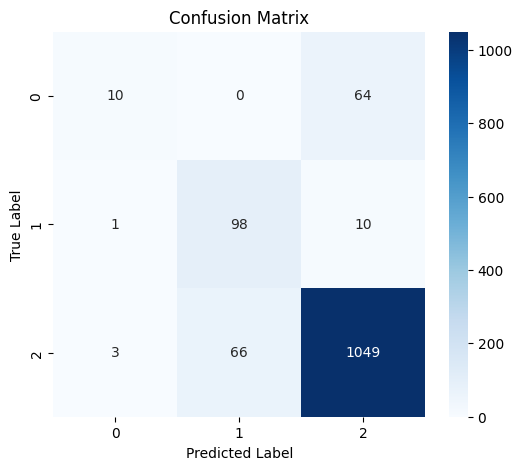

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



# 生成混淆矩阵
cm = confusion_matrix(raw["df4_label"],raw["cause_matches_input_drug"])

# 转换为DataFrame方便显示
cm_df = pd.DataFrame(cm)

# 打印混淆矩阵
print("Confusion Matrix:\n", cm_df)

# 可视化
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [66]:
raw['patient_index'].unique()

array(['patient 24', 'patient 31', 'patient 40'], dtype=object)

In [67]:
for p in ['patient 24', 'patient 31', 'patient 40']:
    print(classification_report(raw[raw['patient_index']==p]["df4_label"], raw[raw['patient_index']==p]["cause_matches_input_drug"]))

              precision    recall  f1-score   support

           0       0.82      0.30      0.44        30
           1       0.82      0.88      0.85        86
           5       0.93      0.96      0.95       444

    accuracy                           0.91       560
   macro avg       0.86      0.71      0.74       560
weighted avg       0.91      0.91      0.90       560

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.70      1.00      0.82        16
           5       0.97      0.98      0.97       370

    accuracy                           0.95       397
   macro avg       0.56      0.66      0.60       397
weighted avg       0.93      0.95      0.94       397

              precision    recall  f1-score   support

           0       0.50      0.03      0.06        33
           1       0.12      0.86      0.22         7
           5       0.89      0.86      0.87       304

    accuracy        

In [71]:
raw.groupby(['df4_label', 'cause_matches_input_drug']).count()

report_id  standard_drug  m_drug_negation  \
df4_label cause_matches_input_drug                                              
0         0                                11             11               11   
          5                                63             63               63   
1         1                                68             68               68   
          5                                41             41               41   
5         0                                 3              3                3   
          1                                29             29               29   
          5                              1086           1086             1086   

                                    standard_symptom  symptom_id  \
df4_label cause_matches_input_drug                                 
0         0                                       11          11   
          5                                       63          63   
1         1                                       68          68   
          5                                       41          41   
5         0                                        3           3   
          1                                       29          29   
          5                                     1086        1086   

                                    patient_index  m_symtom_negation  \
df4_label cause_matches_input_drug                                     
0         0                                    11                 11   
          5                                    63                 63   
1         1                                    68                 68   
          5                                    41                 41   
5         0                                     3                  3   
          1                                    29                 29   
          5                                  1086               1086   

                                    drug_symptom_id  m_in_amf_format  \
df4_label cause_matches_input_drug                                     
0         0                                      11               11   
          5                                      63               63   
1         1                                      68               68   
          5                                      41               41   
5         0                                       3                3   
          1                                      29               29   
          5                                    1086             1086   

                                    m_amf_result  \
df4_label cause_matches_input_drug                 
0         0                                   11   
          5                                   63   
1         1                                   68   
          5                                   41   
5         0                                    3   
          1                                   29   
          5                                 1085   

                                    m_symptom_has_identified_cause  \
df4_label cause_matches_input_drug                                   
0         0                                                     11   
          5                                                     63   
1         1                                                     68   
          5                                                     41   
5         0                                                      3   
          1                                                     29   
          5                                                   1086   

                                    m_cause_matches_input_drug  \
df4_label cause_matches_input_drug                               
0         0                                                 11   
          5                                                 63   
1         1                    

In [72]:
p24 = raw#[raw['patient_index']=='patient 24']
p24[p24['df4_label']!=p24['cause_matches_input_drug']].drop_duplicates(subset=['standard_symptom', 'patient_index'])['drug_symptom_id'].to_list()

['nivolumab_641828005_668',
 'nivolumab_647369991_25061',
 'nivolumab_647369991_19396',
 'nivolumab_649289657_8150',
 'nivolumab_652307472_10595',
 'nivolumab_668258602_527',
 'nivolumab_703589956_2879',
 'nivolumab_740874328_3562',
 'nivolumab_741292027_3333',
 'nivolumab_559311611_5609',
 'nivolumab_561470290_15636',
 'nivolumab_569453342_15476',
 'nivolumab_569453342_13098',
 'nivolumab_569453342_15507',
 'ipilimumab_476231018_2162',
 'ipilimumab_729408283_3890',
 'ipilimumab_729408283_3700']

In [73]:
error_list=['nivolumab_641828005_668',
 'nivolumab_647369991_25061',
 'nivolumab_647369991_19396',
 'nivolumab_649289657_8150',
 'nivolumab_652307472_10595',
 'nivolumab_668258602_527',
 'nivolumab_703589956_2879',
 'nivolumab_740874328_3562',
 'nivolumab_741292027_3333',
 'nivolumab_559311611_5609',
 'nivolumab_561470290_15636',
 'nivolumab_569453342_15476',
 'nivolumab_569453342_13098',
 'nivolumab_569453342_15507',
 'ipilimumab_476231018_2162',
 'ipilimumab_729408283_3890',
 'ipilimumab_729408283_3700']

raw[raw['drug_symptom_id'].isin(error_list)].groupby(['df4_label', 'cause_matches_input_drug']).count()

report_id  standard_drug  m_drug_negation  \
df4_label cause_matches_input_drug                                              
0         5                                 8              8                8   
1         5                                 5              5                5   
5         0                                 2              2                2   
          1                                 2              2                2   

                                    standard_symptom  symptom_id  \
df4_label cause_matches_input_drug                                 
0         5                                        8           8   
1         5                                        5           5   
5         0                                        2           2   
          1                                        2           2   

                                    patient_index  m_symtom_negation  \
df4_label cause_matches_input_drug                                     
0         5                                     8                  8   
1         5                                     5                  5   
5         0                                     2                  2   
          1                                     2                  2   

                                    drug_symptom_id  m_in_amf_format  \
df4_label cause_matches_input_drug                                     
0         5                                       8                8   
1         5                                       5                5   
5         0                                       2                2   
          1                                       2                2   

                                    m_amf_result  \
df4_label cause_matches_input_drug                 
0         5                                    8   
1         5                                    5   
5         0                                    2   
          1                                    2   

                                    m_symptom_has_identified_cause  \
df4_label cause_matches_input_drug                                   
0         5                                                      8   
1         5                                                      5   
5         0                                                      2   
          1                                                      2   

                                    m_cause_matches_input_drug  \
df4_label cause_matches_input_drug                               
0         5                                                  8   
1         5                                                  5   
5         0                                                  2   
          1                                                  2   

                                    m_intervene_found  \
df4_label cause_matches_input_drug                      
0         5                                         3   
1         5                                         2   
5         0                                         0   
          1                                         0   

                                    m_intervene_target_symtom  Label  \
df4_label cause_matches_input_drug                                     
0         5                                                 8      8   
1         5                                                 5      5   
5         0                                                 2      2   
          1                                                 2      2   

                                    drug_negation  symptom_negation  \
df4_label cause_matches_input_drug                                    
0         5                                     8                 8   
1         5                                     5                 5   
5         0                                     2                 2   
          1 

In [ ]:
raw[raw['drug_symptom_id'].isin(error_list)]

In [75]:
train_q4 = pd.read_csv('../q4/train_q4.csv')
train_q4

,report_id,notes,standard_drug,drug_adjacent,standard_symptom,matched_variant,start_index,variant_length,theword,symptom_adjacent,symptom_id,patient_index,split,drug_symptom_id
0,476169085,980261146 6/10/15 476169085clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Abdominal Pain,abdominal pain,2219.0,14.0,abdominal,casino started on sq ifn on 4/14/2014 on mond...,476169085_2219,patient 40,validation,ipilimumab_476169085_2219
1,476169085,980261146 6/10/15 476169085clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Chest Pain,Chest pain,2202.0,10.0,chest,7/14.\nstephanie r casino started on sq ifn on...,476169085_2202,patient 40,validation,ipilimumab_476169085_2202
2,476169085,980261146 6/10/15 476169085clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Diarrhea,diarrhea,2235.0,8.0,diarrhea,on sq ifn on 4/14/2014 on monday-wednesday-fri...,476169085_2235,patient 40,validation,ipilimumab_476169085_2235
3,476169085,980261146 6/10/15 476169085clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Diabetes,DIABETES,6661.0,8.0,diabetes,t- melanoma excision lesion skin trunk right 1...,476169085_6661,patient 40,validation,ipilimumab_476169085_6661
4,476169085,980261146 6/10/15 476169085clinic note chief c...,ipilimumab,"['.\nadditionally, two satellite/in-transit no...",Numbness,numbness,2269.0,8.0,numbness,ednesday-friday.\nher last dose of ifn was 3/1...,476169085_2269,patient 40,validation,ipilimumab_476169085_2269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,853617578,980261146 5/21/18 853617578the james comprehen...,ipilimumab,"[""es comprehensive pituitary center dr. luma m...",Shortness of Breath,dyspnea,7042.0,7.0,dyspnea,(l) fsh latest units: miu/ml 8.6 lh latest un...,853617578_7042,patient 40,validation,ipilimumab_853617578_7042
1452,853617578,980261146 5/21/18 853617578the james comprehen...,ipilimumab,"[""es comprehensive pituitary center dr. luma m...",Edema,edema,8169.0,5.0,edema,"9"") body mass index is 20.03 kg/m_.\ngeneral: ...",853617578_8169,patient 40,validation,ipilimumab_853617578_8169
1453,853617578,980261146 5/21/18 853617578the james comprehen...,ipilimumab,"[""es comprehensive pituitary center dr. luma m...",Cough,Cough,6969.0,5.0,cough,50.0 pg/ml <5.0 (l) cortisol latest ref range...,853617578_6969,patient 40,validation,ipilimumab_853617578_6969
1454,853617578,980261146 5/21/18 853617578the james comprehen...,ipilimumab,"[""es comprehensive pituitary center dr. luma m...",Dizziness,dizzy,1595.0,5.0,dizzy,"the chest wall, same site of initial lesion: s...",853617578_1595,patient 40,validation,ipilimumab_853617578_1595


In [78]:
error_list = ['nivolumab_641828005_668',
 'nivolumab_647369991_25061',
 'nivolumab_647369991_19396',
 'nivolumab_649289657_8150',
 'nivolumab_652307472_10595',
 'nivolumab_668258602_527',
 'nivolumab_703589956_2879',
 'nivolumab_740874328_3562',
 'nivolumab_741292027_3333',
 'nivolumab_559311611_5609',
 'nivolumab_561470290_15636',
 'nivolumab_569453342_15476',
 'nivolumab_569453342_13098',
 'nivolumab_569453342_15507',
 'ipilimumab_476231018_2162',
 'ipilimumab_729408283_3890',
 'ipilimumab_729408283_3700']

def label_convert(x):
    if x==1:
        return 'highly_suspect_drug_related'
    elif x==0:
        return 'highly_suspect_other_etiology'
    elif x==5:
        return 'other'

errors = ''

for i in range(len(error_list)):
    current_error = f''' example_id : {str(i)}
                Patient Note:{train_q4[train_q4['drug_symptom_id']==error_list[i]]['symptom_adjacent'].iloc[0]},
                **INPUT DRUG** : {train_q4[train_q4['drug_symptom_id']==error_list[i]]['standard_drug'].iloc[0]},
                LLM_output: {label_convert(raw[raw['drug_symptom_id']==error_list[i]]['cause_matches_input_drug'].iloc[0])}, 
                LLM_reasoning: {df4[df4['drug_symptom_id']==error_list[i]]['llm_output'].iloc[0]},
                Lable: {label_convert(raw[raw['drug_symptom_id']==error_list[i]]['df4_label'].iloc[0])},
                Is the output correct compared to the label : < yes or no , and your reasoning >
                Is the output correctly following the given prompt : < yes or no , and your reasoning >
                Is the prompt correctly describing the task shown by the input - label pair : < yes or no , and your reasoning>
                To output the correct label , is it necessary to edit the prompt : < yes or no , and your reasoning >
                If yes , provide detailed analysis and actionable suggestions to edit the prompt : < analysis and suggestions >
                ###
                '''
    # print(current_error)
    errors = errors + current_error
    # break
    
    

In [79]:
errors

' example_id : 0\n                Patient Note:name 4**] [**Known patient firstname 5**] is a 74 y.o. male ex-smoker with metastatic driver negative adenosquamous lung cancer here for follow up appointment.\n_sent_ Since his last visit, [**Doctor Last Name 6**] has completed radiation therapy and the pain in his arm and back have significantly improved.\n_sent_ [**Doctor Last Name **] is taking pain meds about twice a day.\n_sent_ [**Doctor Last Name **] has had intermittent constipation and took an enema yesterday which resulted in a day\'s of <symptom> diarrhea </symptom>.\n_sent_ [**Doctor Last Name **] also has completed his dental work down in Florida.\n_sent_ [**Doctor Last Name **] has diminished appetite but otherwise has been feeling overall pretty good.\n_sent_ No new focal neurologic sym ptms. Energy is up and down but [**Doctor Last Name 6**] tries to remain active by going to the gym.\n_sent_ [**Doctor Last Name **] does have trouble with anxiety and usually takes a Xanax 

In [75]:
raw[(raw['df4_label']==5) & (raw['cause_matches_input_drug']==0)][['report_id', 'standard_drug', 'm_drug_negation', 'standard_symptom',
       'symptom_id', 'patient_index', 'm_symtom_negation', 'drug_symptom_id', 'm_symptom_has_identified_cause',
       'm_cause_matches_input_drug', 'm_intervene_found',
       'm_intervene_target_symtom', 'Label', 'drug_negation',
       'symptom_negation', 'in_amf_format', 'cause_matches_input_drug',
       'df4_label']]
# raw_m[(raw_m['Label']==2) & (raw_m['model']==0)][['report_id', 'standard_drug', 'm_drug_negation', 'standard_symptom',
#        'symptom_id', 'patient_index', 'm_symtom_negation', 'drug_symptom_id', 'm_symptom_has_identified_cause',
#        'm_cause_matches_input_drug', 'm_intervene_found',
#        'm_intervene_target_symtom', 'drug_negation',
#        'symptom_negation', 'in_amf_format', 'cause_matches_input_drug',
#        'df4_label', 'intervene_target_symtom']]

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_symptom_has_identified_cause,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation,symptom_negation,in_amf_format,cause_matches_input_drug,df4_label
538,745643274,nivolumab,0,Cough,745643274_561,patient 24,0,nivolumab_745643274_561,0,0,NaN,0,2,0,0,0,0,5
644,559311611,nivolumab,0,Syncope,559311611_15053,patient 31,0,nivolumab_559311611_15053,0,0,NaN,0,2,0,0,0,0,5
671,561470290,nivolumab,0,Syncope,561470290_15636,patient 31,0,nivolumab_561470290_15636,0,0,NaN,0,2,0,0,0,0,5
678,569453342,nivolumab,0,Dermatitis,569453342_13098,patient 31,0,nivolumab_569453342_13098,0,0,NaN,0,2,0,0,0,0,5
679,569453342,nivolumab,0,Dermatitis,569453342_16460,patient 31,0,nivolumab_569453342_16460,0,0,NaN,0,2,0,0,0,0,5
743,588397690,nivolumab,0,Dizziness,588397690_2912,patient 31,0,nivolumab_588397690_2912,0,0,NaN,0,2,0,0,0,0,5
834,619245142,nivolumab,0,Dizziness,619245142_2932,patient 31,0,nivolumab_619245142_2932,0,0,NaN,0,2,0,0,0,0,5
894,628222803,nivolumab,0,Syncope,628222803_15970,patient 31,0,nivolumab_628222803_15970,0,0,NaN,0,2,0,0,0,0,5
1168,742730480,ipilimumab,0,Low TSH,742730480_16154,patient 40,0,ipilimumab_742730480_16154,0,0,NaN,0,2,0,1,0,0,5
1256,795087734,ipilimumab,0,Tachycardia,795087734_2264,patient 40,0,ipilimumab_795087734_2264,0,0,NaN,0,2,0,0,0,0,5


In [76]:
# raw.to_csv('output_27b_think.csv')

df4[df4['drug_symptom_id'] =='nivolumab_559311611_3225'].iloc[0]['llm_output']

{'symptom': 'prurit ic, scaling rash',
 'input_drug': 'nivolumab',
 'etiology_classification': 'other',
 'supporting_evidence': '[**Doctor Last Name **] is using desonide for <symptom> prurit </symptom>ic, scaling rash (arms and back).',
 'reasoning': 'The clinical note mentions the symptom and its treatment with desonide, but does not explicitly link the symptom to the input drug, nivolumab. There is no mention of nivolumab in relation to the rash.'}

# df5

In [77]:
df5['llm_output'].iloc[0]

{'step_1': {'sentence_containing_symptom': "[**Doctor Last Name **] has had intermittent constipation and took an enema yesterday which resulted in a day's of <symptom> diarrhea </symptom>.",
  'symptom_identified': 'diarrhea'},
 'step_2': {'management_found': False,
  'management_description': 'No management for diarrhea found'},
 'step_3': {'management_category': 'No Management Mentioned',
  'supporting_evidence': 'No specific management actions were mentioned for the diarrhea in the provided text.'}}

In [78]:
# df5['intervene_found'] = df5['llm_output'].apply(lambda x: x['final_assessment']['ici_intervention_present'] if x!='parse_failed' else 'parse_failed')
# df5['intervene_target_symtom'] = df5['llm_output'].apply(lambda x: x['final_assessment']['intervention_targets_symptom'] if x!='parse_failed' else 'parse_failed')

df5['intervene_found'] = df5['llm_output'].apply(lambda x: x['step_2']['management_found'] if x!='parse_failed' else 'parse_failed')
df5['intervene_target_symtom'] = df5['llm_output'].apply(lambda x: x['step_3']['management_category'] if x!='parse_failed' else 'parse_failed')

In [79]:
df5['intervene_target_symtom'].unique()

array(['No Management Mentioned', 'Other Management', 'parse_failed',
       'Steroid Use', 'Immunotherapy Hold/Delay'], dtype=object)

In [80]:
# df5['intervene_target_symtom'] = df5['intervene_target_symtom'].apply(lambda x: 1 if x==True else 0)

df5['intervene_target_symtom'] = df5['intervene_target_symtom'].apply(lambda x: 1 if x in ['Steroid Use', 'Immunotherapy Hold/Delay'] else 0)

In [81]:
df_grouped = df5[['symptom_id', 'intervene_target_symtom']].drop_duplicates()

In [82]:
raw = raw.merge(df_grouped, on=['symptom_id'], how='left')

In [83]:
raw['m_intervene_target_symtom'].unique()
raw['m_intervene_target_symtom'] = raw['m_intervene_target_symtom'].astype(int)

In [84]:
print(classification_report(raw["m_intervene_target_symtom"], raw["intervene_target_symtom"]))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1155
           1       0.73      0.82      0.77       146

    accuracy                           0.95      1301
   macro avg       0.85      0.89      0.87      1301
weighted avg       0.95      0.95      0.95      1301



# Overall

In [85]:
def classify_triplets(triplets):
    triplets_set = set(tuple(t) for t in triplets)  # 转成set方便判断

    # 定义组合
    return1_set = {(1,1,1), (1,1,0), (1,5,1), (0,0,1)}
    return2_set = {(1,5,0), (0,0,0)}
    return0_set = {(1,0,0), (1,0,1)}

    if triplets_set & return1_set:
        return 1
    elif triplets_set & return2_set:
        return 2
    elif triplets_set & return0_set:
        return 0
    else:
        return 2

def aggregation0(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['symptom_has_identified_cause', 
                     'cause_matches_input_drug', 
                     'intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['symptom_has_identified_cause', 
                 'cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)


def aggregation1(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    if len(temp[temp['cause_matches_input_drug']==1])>0:
                        return 1
                    elif len(temp[temp['cause_matches_input_drug']==5])>0:
                        temp = temp[temp['cause_matches_input_drug']==5]
                        if len(temp[temp['intervene_target_symtom']==1])>0:
                            return 1
                        else:
                            return 2
                    else:
                        return 0
            else:
                temp = temp[temp['in_amf_format']==0]
                if len(temp[temp['cause_matches_input_drug']==1])>0:
                    return 1
                elif len(temp[temp['cause_matches_input_drug']==5])>0:
                    temp = temp[temp['cause_matches_input_drug']==5]
                    if len(temp[temp['intervene_target_symtom']==1])>0:
                        return 1
                    else:
                        return 2
                else:
                    return 0


def aggregation3(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    if len(temp[temp['cause_matches_input_drug']==1])>0:
                        return 1
                    elif len(temp[temp['cause_matches_input_drug']==5])>0:
                        temp = temp[temp['cause_matches_input_drug']==5]
                        if len(temp[temp['intervene_target_symtom']==1])>0:
                            return 1
                        else:
                            return 2
                    else:
                        temp = temp[temp['cause_matches_input_drug']==0]
                        if len(temp[temp['intervene_target_symtom']==1])>0:
                            return 1
                        else:
                            return 0
                        # return 0
            else:
                temp = temp[temp['in_amf_format']==0]
                if len(temp[temp['cause_matches_input_drug']==1])>0:
                    return 1
                elif len(temp[temp['cause_matches_input_drug']==5])>0:
                    temp = temp[temp['cause_matches_input_drug']==5]
                    if len(temp[temp['intervene_target_symtom']==1])>0:
                        return 1
                    else:
                        return 2
                else:
                    temp = temp[temp['cause_matches_input_drug']==0]
                    if len(temp[temp['intervene_target_symtom']==1])>0:
                        return 1
                    else:
                        return 0



def aggregation2(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    if len(temp[temp['df4_label']==1])>0:
                        return 1
                    elif len(temp[temp['df4_label']==5])>0:
                        temp = temp[temp['df4_label']==5]
                        if len(temp[temp['intervene_target_symtom']==1])>0:
                            return 1
                        else:
                            return 2
                    else:
                        return 0
            else:
                temp = temp[temp['in_amf_format']==0]
                if len(temp[temp['df4_label']==1])>0:
                    return 1
                elif len(temp[temp['df4_label']==5])>0:
                    temp = temp[temp['df4_label']==5]
                    if len(temp[temp['intervene_target_symtom']==1])>0:
                        return 1
                    else:
                        return 2
                else:
                    return 0


                

def aggregation_drug(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['m_drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['symptom_has_identified_cause', 
                     'cause_matches_input_drug', 
                     'intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['symptom_has_identified_cause', 
                 'cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)
                

def aggregation_m(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['symptom_has_identified_cause', 
                     'm_cause_matches_input_drug', 
                     'intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['symptom_has_identified_cause', 
                 'm_cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)
                

def aggregation_mi(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['symptom_has_identified_cause', 
                     'm_cause_matches_input_drug', 
                     'm_intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['symptom_has_identified_cause', 
                 'm_cause_matches_input_drug', 
                 'm_intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)
                

def aggregation_i(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['symptom_has_identified_cause', 
                     'cause_matches_input_drug', 
                     'm_intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['symptom_has_identified_cause', 
                 'cause_matches_input_drug', 
                 'm_intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)
                

def aggregation_cm(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['m_symptom_has_identified_cause', 
                     'm_cause_matches_input_drug', 
                     'intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['m_symptom_has_identified_cause', 
                 'm_cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)

def aggregation_cmi(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['m_symptom_has_identified_cause', 
                     'm_cause_matches_input_drug', 
                     'm_intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['m_symptom_has_identified_cause', 
                 'm_cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)


def aggregation_c(df, report_id, standard_drug, standard_symptom):
    temp = df[(df['report_id']==report_id) & (df['standard_drug']==standard_drug) & (df['standard_symptom']==standard_symptom)]
    if temp['drug_negation'].mean() == 1:
        return 0
    else:
        if len(temp[temp['symptom_negation']==0])==0:
            return 0
        else:
            temp = temp[temp['symptom_negation']==0]
            if len(temp[temp['in_amf_format']==1]) > 0:
                if len(temp[temp['in_amf_format']==1]) == len(temp):
                    amf = temp[temp['in_amf_format']==1]
                    return 0
                else:
                    temp = temp[temp['in_amf_format']==0]
                    triplets = temp[['m_symptom_has_identified_cause', 
                     'cause_matches_input_drug', 
                     'intervene_target_symtom']].values.tolist() 
                    return classify_triplets(triplets)
            else:
                temp = temp[temp['in_amf_format']==0]
                triplets = temp[['m_symptom_has_identified_cause', 
                 'cause_matches_input_drug', 
                 'intervene_target_symtom']].values.tolist() 
                return classify_triplets(triplets)
                
                

In [86]:
agg = raw.groupby(['report_id', 'standard_drug', 'standard_symptom'],as_index=False).agg({'Label':'mean'})
agg['Label'] = agg['Label'].astype(int)

In [87]:
agg

,report_id,standard_drug,standard_symptom,Label
0,476169085,ipilimumab,Abdominal Pain,0
1,476169085,ipilimumab,Chest Pain,0
2,476169085,ipilimumab,Diabetes,0
3,476169085,ipilimumab,Diarrhea,0
4,476169085,ipilimumab,Edema,0
...,...,...,...,...
691,853617578,ipilimumab,Edema,0
692,853617578,ipilimumab,Hypothyroid,2
693,853617578,ipilimumab,Numbness,0
694,853617578,ipilimumab,Shortness of Breath,0


In [88]:
# agg['model0'] = agg.apply(lambda x: aggregation(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
agg['model'] = agg.apply(lambda x: aggregation1(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_drug'] = agg.apply(lambda x: aggregation_drug(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_m'] = agg.apply(lambda x: aggregation_m(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_mi'] = agg.apply(lambda x: aggregation_mi(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_i'] = agg.apply(lambda x: aggregation_i(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_cm'] = agg.apply(lambda x: aggregation_cm(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_cmi'] = agg.apply(lambda x: aggregation_cmi(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)
# agg['model_c'] = agg.apply(lambda x: aggregation_c(raw, x['report_id'], x['standard_drug'], x['standard_symptom']), axis=1)

In [89]:
agg['model'].unique()

array([0, 2, 1])

In [90]:
agg[agg['model'].isna()]

,report_id,standard_drug,standard_symptom,Label,model


In [91]:
agg['Label'].unique()

array([0, 2, 1])

In [92]:
# All 27b

from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       405
           1       0.64      0.97      0.78        71
           2       0.90      0.72      0.80       220

    accuracy                           0.89       696
   macro avg       0.83      0.89      0.84       696
weighted avg       0.90      0.89      0.89       696



In [93]:

df200s = pd.read_excel("output_27b_200.xlsx", sheet_name=None)

# `dfs` is now a dict of DataFrames
# You can access each sheet by its name
for name, df in df200s.items():
    print(f"Sheet: {name}, Shape: {df.shape}")

Sheet: p1, Shape: (75, 7)
Sheet: p2, Shape: (200, 7)
Sheet: p3, Shape: (200, 7)
Sheet: p4, Shape: (200, 7)
Sheet: p5, Shape: (200, 7)


In [94]:
df200 = df200s['p2'].copy()

,Label,model
count,696.000000,696.000000
mean,0.734195,0.622126
std,0.910234,0.851253
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,1.000000
max,2.000000,2.000000


In [108]:
df200['check200'] = 1
df200['report_id'] = df200['report_id'].astype(str)
agg1 = agg.merge(df200[['report_id','standard_drug', 'standard_symptom','check200']], on=['report_id','standard_drug', 'standard_symptom'], how='left' )
agg1 = agg1[agg1['check200']==1]

In [109]:
from sklearn.metrics import classification_report

y_true = agg1['Label']
y_pred = agg1['model']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       106
           1       0.71      0.81      0.76        21
           2       0.85      0.69      0.76        58

    accuracy                           0.86       185
   macro avg       0.82      0.82      0.82       185
weighted avg       0.86      0.86      0.86       185



Confusion Matrix:
      0   1    2
0  392   0   13
1    1  61    9
2   40  32  148


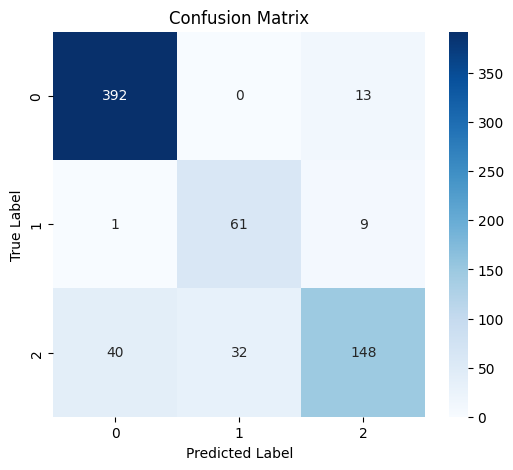

In [88]:
# 生成混淆矩阵
cm = confusion_matrix(y_true, y_pred)

# 转换为DataFrame方便显示
cm_df = pd.DataFrame(cm)

# 打印混淆矩阵
print("Confusion Matrix:\n", cm_df)

# 可视化
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [111]:
raw_m = raw.merge(agg[['report_id', 'standard_drug', 'standard_symptom', 'model']], on=['report_id', 'standard_drug', 'standard_symptom'], how='left')

In [109]:
agg.columns

Index(['report_id', 'standard_drug', 'standard_symptom', 'Label', 'model'], dtype='object')

In [91]:
raw[(raw['report_id']=='559311611') & (raw['standard_symptom'] == 'Arthritis')]

,report_id,standard_drug,m_drug_negation,standard_symptom,symptom_id,patient_index,m_symtom_negation,drug_symptom_id,m_in_amf_format,m_amf_result,...,m_cause_matches_input_drug,m_intervene_found,m_intervene_target_symtom,Label,drug_negation,symptom_negation,in_amf_format,cause_matches_input_drug,df4_label,intervene_target_symtom
618,559311611,nivolumab,0,Arthritis,559311611_5609,patient 31,0,nivolumab_559311611_5609,0,0.0,...,0,NaN,0,2,0,1,0,5,0,0
619,559311611,nivolumab,0,Arthritis,559311611_7597,patient 31,0,nivolumab_559311611_7597,0,0.0,...,0,NaN,0,2,0,0,1,5,5,0


In [92]:
raw.to_csv('raw_1124.csv', index=False)

In [107]:
agg[(agg['Label']==2) & (agg['model']==0)]

,report_id,standard_drug,standard_symptom,Label,model
46,512065771,nivolumab,Arthritis,2,0
57,535896448,nivolumab,Arthritis,2,0
65,535896448,nivolumab,Increased TSH,2,0
80,559311611,nivolumab,Arthritis,2,0
89,559311611,nivolumab,Pruritus,2,0
94,561470290,nivolumab,Arthritis,2,0
108,569453342,nivolumab,Arthritis,2,0
112,569453342,nivolumab,Dermatitis,2,0
119,569453342,nivolumab,Pruritus,2,0
133,582232391,nivolumab,Arthritis,2,0


In [110]:
# All 27b

from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       405
           1       0.69      0.89      0.78        71
           2       0.86      0.78      0.82       220

    accuracy                           0.89       696
   macro avg       0.83      0.87      0.85       696
weighted avg       0.89      0.89      0.89       696



In [81]:
agg[agg['Label']!=agg['model']]

,report_id,standard_drug,standard_symptom,Label,model
27,501085236,nivolumab,Fatigue,2,1
46,512065771,nivolumab,Arthritis,2,0
50,512065771,nivolumab,Diarrhea,2,1
57,535896448,nivolumab,Arthritis,2,0
65,535896448,nivolumab,Increased TSH,2,0
...,...,...,...,...,...
674,812663424,ipilimumab,Diarrhea,2,1
675,812663424,ipilimumab,Dizziness,2,1
685,853617578,ipilimumab,Adrenal Insufficiency,2,1
689,853617578,ipilimumab,Diarrhea,2,1


In [101]:
# All 27b

from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       405
           1       0.72      0.87      0.79        71
           2       0.89      0.75      0.81       220

    accuracy                           0.89       696
   macro avg       0.84      0.86      0.85       696
weighted avg       0.89      0.89      0.88       696



In [102]:
# All 27b

from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_c']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       405
           1       0.77      0.76      0.77        71
           2       0.90      0.84      0.87       220

    accuracy                           0.91       696
   macro avg       0.87      0.86      0.86       696
weighted avg       0.91      0.91      0.91       696



In [95]:
# drug

from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_drug']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       405
           1       0.72      0.89      0.80        71
           2       0.89      0.76      0.82       220

    accuracy                           0.89       696
   macro avg       0.85      0.87      0.85       696
weighted avg       0.89      0.89      0.89       696



In [113]:
from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_m']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       405
           1       0.78      0.75      0.76        71
           2       0.86      0.79      0.82       220

    accuracy                           0.88       696
   macro avg       0.85      0.83      0.84       696
weighted avg       0.88      0.88      0.88       696



In [114]:
from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_mi']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       405
           1       0.98      0.69      0.81        71
           2       0.85      0.85      0.85       220

    accuracy                           0.90       696
   macro avg       0.92      0.83      0.87       696
weighted avg       0.90      0.90      0.90       696



In [115]:
from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_i']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       405
           1       0.87      0.87      0.87        71
           2       0.89      0.85      0.87       220

    accuracy                           0.92       696
   macro avg       0.90      0.89      0.90       696
weighted avg       0.92      0.92      0.92       696



In [117]:
from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_cm']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       405
           1       0.81      0.97      0.88        71
           2       0.94      0.84      0.89       220

    accuracy                           0.93       696
   macro avg       0.90      0.93      0.91       696
weighted avg       0.93      0.93      0.93       696



In [118]:
from sklearn.metrics import classification_report

y_true = agg['Label']
y_pred = agg['model_cmi']

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       405
           1       0.81      0.97      0.88        71
           2       0.94      0.84      0.89       220

    accuracy                           0.93       696
   macro avg       0.90      0.93      0.91       696
weighted avg       0.93      0.93      0.93       696



In [100]:
agg[agg['model']!=agg['Label']].groupby(['Label', 'model'], as_index = False).agg({'report_id':'count'})

,Label,model,report_id
0,0,2,15
1,1,0,1
2,1,2,5
3,2,0,26
4,2,1,23


In [87]:
agg[(agg['Label']==2) & (agg['model']==0)]

,report_id,standard_drug,standard_symptom,Label,model,model_drug,model_cm,model_cmi,model_i,model_c
17,501075426,nivolumab,Arthritis,2,0,2,2,2,0,0
22,501075426,nivolumab,Fatigue,2,0,2,2,2,0,0
23,501075426,nivolumab,Hypertension,2,0,2,2,2,0,0
24,501075426,nivolumab,Hypothyroid,2,0,2,2,2,0,0
46,512065771,nivolumab,Arthritis,2,0,0,0,0,0,0
57,535896448,nivolumab,Arthritis,2,0,0,0,0,0,0
65,535896448,nivolumab,Increased TSH,2,0,0,0,0,0,0
80,559311611,nivolumab,Arthritis,2,0,0,0,0,0,0
84,559311611,nivolumab,Dizziness,2,0,2,2,2,0,0
85,559311611,nivolumab,Edema,2,0,2,2,2,0,0


In [85]:
df2[df2['drug_symptom_id'] =='nivolumab_649289657_8150'].iloc[0]['llm_output']

{'step1_extracted_symptom': 'Fatigue',
 'step1_complete_sentence': 'His <symptom> Fatigue </symptom> may be related to his stress or potentially endocrine dysfunction from the nivolumab.',
 'step2_analysis': {'label': 'NO CLEAR EVIDENCE OF SYMPTOM IN PATIENT',
  'reasoning': "The sentence states that the patient's fatigue 'may be related' to other factors, indicating a potential cause or association rather than a confirmed presence or history of the symptom in the patient. This falls under the 'Hypothetical / Conditional / Undiagnosed' category."},
 'summary': "The symptom 'Fatigue' is mentioned as a potential issue related to stress or medication side effects, but the sentence does not confirm its presence in the patient."}

In [86]:
df5[df5['symptom_id'] =='744837781_9842'].iloc[0]['llm_output']

{'step1_symptom_extraction': {'extracted_symptom': 'diarrhea',
  'containing_sentences': ['HPI: Decreased oral intake, fatigue, <symptom> diarrhea </symptom>, cough.'],
  'symptom_location_context': 'Found in the History of Present Illness (HPI) section.'},
 'step2_intervention_detection': {'interventions_found': [{'intervention_type': 'steroid_use',
    'intervention_description': 'prednisone',
    'context_sentence': 'nivolumab induced colitis that improved with prednisone'}],
  'determination': 'YES',
  'reasoning': "The note mentions 'prednisone' use in the context of 'nivolumab induced colitis', which is an ICI toxicity. Prednisone is a steroid, meeting the criteria for an ICI toxicity intervention."},
 'step3_symptom_intervention_relationship': {'analysis_applicable': True,
  'determination': 'YES',
  'reasoning': "The intervention 'prednisone' is explicitly mentioned as improving 'nivolumab induced colitis'. Colitis commonly presents with diarrhea. Therefore, the steroid was use

# +++++++++Appendix++++++++++++

In [3]:
p1.columns

Index(['report_id', 'patient_index', 'standard_drug', 'index', 'llm_output'], dtype='object')

In [4]:
p1[['report_id', 'standard_drug', 'index','llm_output']]

,report_id,standard_drug,index,llm_output
0,812663424,ipilimumab,0,"('non_negation', [{'step1_extracted_drug_objec..."
1,536183429,ipilimumab,1,"('non_negation', [{'step1_extracted_drug_objec..."
2,714849544,ipilimumab,2,"('non_negation', [{'step1_extracted_drug_objec..."
3,503238928,ipilimumab,3,"('drug_negation', [{'step1_extracted_drug_obje..."
4,751664786,ipilimumab,4,"('non_negation', [{'step1_extracted_drug_objec..."
...,...,...,...,...
70,594831699,nivolumab,70,"('drug_negation', [{'step1_extracted_drug_obje..."
71,619245142,nivolumab,71,"('drug_negation', [{'step1_extracted_drug_obje..."
72,588397690,nivolumab,72,"('non_negation', [{'step1_extracted_drug_objec..."
73,559311611,nivolumab,73,"('drug_negation', [{'step1_extracted_drug_obje..."


In [5]:
import ast

p1['llm_output'] = p1['llm_output'].apply(ast.literal_eval)

In [6]:
p1['drug_use'] = p1['llm_output'].apply(lambda x : x[0])

In [7]:
p1.groupby('drug_use').size()

drug_use
drug_negation    24
non_negation     51
dtype: int64

In [8]:
p1[p1['drug_use']== 'drug_negation'].loc[14].llm_output

('drug_negation',
 [{'step1_extracted_drug_object': 'IPILIMUMAB',
   'step2_summary_sentence': 'The patient is scheduled for cycle 2 (c2) of adjuvant IPILIMUMAB 10 mg/kg.',
   'step3_analysis': {'q1_drug_match': {'answer': 'DRUG MATCH',
     'reasoning': "The extracted drug object 'IPILIMUMAB' exactly matches the input drug 'ipilimumab'."},
    'q2_temporal_analysis': {'answer': 'NO',
     'reasoning': 'The sentence indicates the patient is scheduled for c2, meaning the drug administration is planned for the same day as the note or in the future, not before the note was written.'}},
   'final_result': 'DRUG NOT TAKEN',
   'summary': "The tagged drug 'IPILIMUMAB' matches ipilimumab, but the sentence indicates the administration is scheduled for cycle 2, which is not before the note was written."},
  {'step1_extracted_drug_object': 'IPILIMUMAB',
   'step2_summary_sentence': 'The patient has been cleared for cycle 2 of IPILIMUMAB today.',
   'step3_analysis': {'q1_drug_match': {'answer': 

In [17]:
p1[p1['drug_use']== 'drug_negation'].loc[30].llm_output

('drug_negation',
 [{'step1_extracted_drug_object': 'NIVOLUMAB',
   'step2_summary_sentence': 'NIVOLUMAB is administered IV by Intravenous route.',
   'step3_analysis': {'q1_drug_match': {'answer': 'DRUG MATCH',
     'reasoning': "The extracted drug object 'NIVOLUMAB' matches the input drug 'nivolumab'."},
    'q2_temporal_analysis': {'answer': 'NO',
     'reasoning': 'The sentence describes the route of administration but does not provide information about whether the drug was taken before the note was written. It does not mention cycles, past dates, or discontinuation.'}},
   'final_result': 'DRUG NOT TAKEN',
   'summary': "The tagged drug 'NIVOLUMAB' matches nivolumab, but the sentence only describes the administration route and does not indicate prior administration."}])

In [8]:
p1[p1['drug_use']== 'drug_negation']

,report_id,patient_index,standard_drug,index,llm_output,drug_use
3,503238928,patient 40,ipilimumab,3,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
6,503246625,patient 40,ipilimumab,6,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
9,573481523,patient 40,ipilimumab,9,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
10,688635476,patient 40,ipilimumab,10,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
11,613487317,patient 40,ipilimumab,11,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
12,536184662,patient 40,ipilimumab,12,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
13,704865238,patient 40,ipilimumab,13,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
14,721695460,patient 40,ipilimumab,14,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
15,476231018,patient 40,ipilimumab,15,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
16,685826028,patient 40,ipilimumab,16,"(drug_negation, [{'step1_extracted_drug_object...",drug_negation
